In [1]:
import pandas as pd 
import numpy as np
import os 
import xarray as xr 
import matplotlib.pyplot as plt
import cmocean as cmo 
import pandas as pd 
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import numpy as np
import matplotlib.dates as mdates

# Start date 
start_date = '2024-08-06'
end_date = '2024-08-28' 

Dates = pd.date_range(start_date, end_date, freq='10s')



def format_date_ax(ax):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)

In [2]:
mixed_depth = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/mixed_layer/TempDens_parametersbydepth.csv")
mixed_depth = mixed_depth.loc[mixed_depth.SITE == "WEB"]
print(mixed_depth.columns)
mixed_depth['time'] = pd.to_datetime(mixed_depth['TIMESTAMP'])
mixed_depth.loc[mixed_depth["Depth_MixedLayer_Max_60min_movavg"] > 5] = np.nan

# print(mixed_depth["Depth_MixedLayer_Max_60min_movavg"])

# fig = plt.figure(figsize=(10, 4))
# plt.plot(mixed_depth['time'], mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-') 

zscales = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/mixed_layer/Diffusivity_zscales.csv")
zscales['time'] = pd.to_datetime(zscales.timestamp_round15) 
zscales['photic'] = zscales["z_mixed_60minmovavg_sd"]
zscales = zscales.loc[zscales.site == "WEB"]
zscales.drop(columns=['site', 'date', 'microctd_timestamp', 'timestamp_round15'], inplace=True)
# print(zscales.columns)


hydro = xr.open_dataset("/global/homes/s/siennaw/scratch/siennaw/two_species/adjoint_phytoplankton/run_hydro/HYDRO_AUGUST6-28.nc")
htime = Dates

temp = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/turbulence-model/data/forcing_data/data/Temperature_processed.csv")
temp = temp.loc[temp.SITE == "WEB"]
temp = temp.loc[temp.STAT == "Average"]
temp.reset_index(inplace=True)
temp['time'] = pd.to_datetime(temp['TIMESTAMP'])
temp.drop(columns=['STAT', 'SITE', "SENSOR", "Interval", "TIMESTAMP"], inplace=True)
temp['day'] = temp['time'].dt.day
# print(temp)


Index(['TIMESTAMP', 'DEPTH', 'TEMPERATURE', 'DENSITY', 'SITE',
       'Dens_Average_MixedCond', 'Dens_Min', 'Dens_Max', 'Dens_MaxDiff',
       'Temp_Average_MixedCond', 'Temp_Min', 'Temp_Max', 'Temp_MaxDiff',
       'PE_Anomaly (J/m^2)', 'dPEA_dt (J/m^2)', 'PE_Anomaly (J/m^3)',
       'dPEA_dt (J/m^3)', 'dpavg_dt', 'N_squared', 'dp_dz', 'TimeofDay',
       'Interval', 'dp_dz_Max', 'Depth_MixedLayer', 'RRI_WaterLevel',
       'Depth_MixedLayer_Max', 'Depth_MixedLayer_Min',
       'Depth_MixedLayer_Max_60min_movavg',
       'Depth_MixedLayer_Min_60min_movavg'],
      dtype='object')


/tmp/ipykernel_409908/1150437505.py:20: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  hydro = xr.open_dataset("/global/homes/s/siennaw/scratch/siennaw/two_species/adjoint_phytoplankton/run_hydro/HYDRO_AUGUST6-28.nc")


In [3]:
days = range(6, 28)

days_fn = ["august_%02d" % day for day in days]
print(days_fn)

guess = {} 

# get list of files in finished/
read_in = os.listdir('finished/')
print(read_in)

import re

for file in read_in:
    if file.startswith('forward_1_') or file.startswith('adjoint'):
        pass
    else:
        # print(file)
        match = re.search(r'(\d+)(?=\.nc$)', file)
        day = match.group(1)
        guess[day] = xr.open_dataset('finished/%s' % (file), decode_timedelta=False)
        print("Opened day ", day)
        z = guess[day].z.values

    # Get last two digits 

# for i in read_in: #range(1, NITER):
#     guess[i] = xr.open_dataset('finished/forward__%s.nc' % (days_fn), decode_timedelta=False)

['august_06', 'august_07', 'august_08', 'august_09', 'august_10', 'august_11', 'august_12', 'august_13', 'august_14', 'august_15', 'august_16', 'august_17', 'august_18', 'august_19', 'august_20', 'august_21', 'august_22', 'august_23', 'august_24', 'august_25', 'august_26', 'august_27']
['adjoint_56_august_09.nc', 'adjoint_1_august_11.nc', 'forward_11_august_21.nc', 'adjoint_9_august_26.nc', 'adjoint_1_august_22.nc', 'forward_1_august_24.nc', 'adjoint_79_august_13.nc', 'adjoint_6_august_15.nc', 'forward_14_august_15.nc', 'forward_78_august_12.nc', 'adjoint_18_august_14.nc', 'adjoint_1_august_20.nc', 'forward_1_august_13.nc', 'forward_1_august_22.nc', 'forward_1_august_11.nc', 'forward_72_august_10.nc', 'adjoint_1_august_15.nc', 'adjoint_1_august_21.nc', 'forward_76_august_19.nc', 'forward_1_august_20.nc', 'adjoint_84_august_24.nc', 'adjoint_76_august_22.nc', 'adjoint_72_august_10.nc', 'adjoint_13_august_07.nc', 'forward_1_august_18.nc', 'adjoint_1_august_27.nc', 'forward_1_august_25.nc'

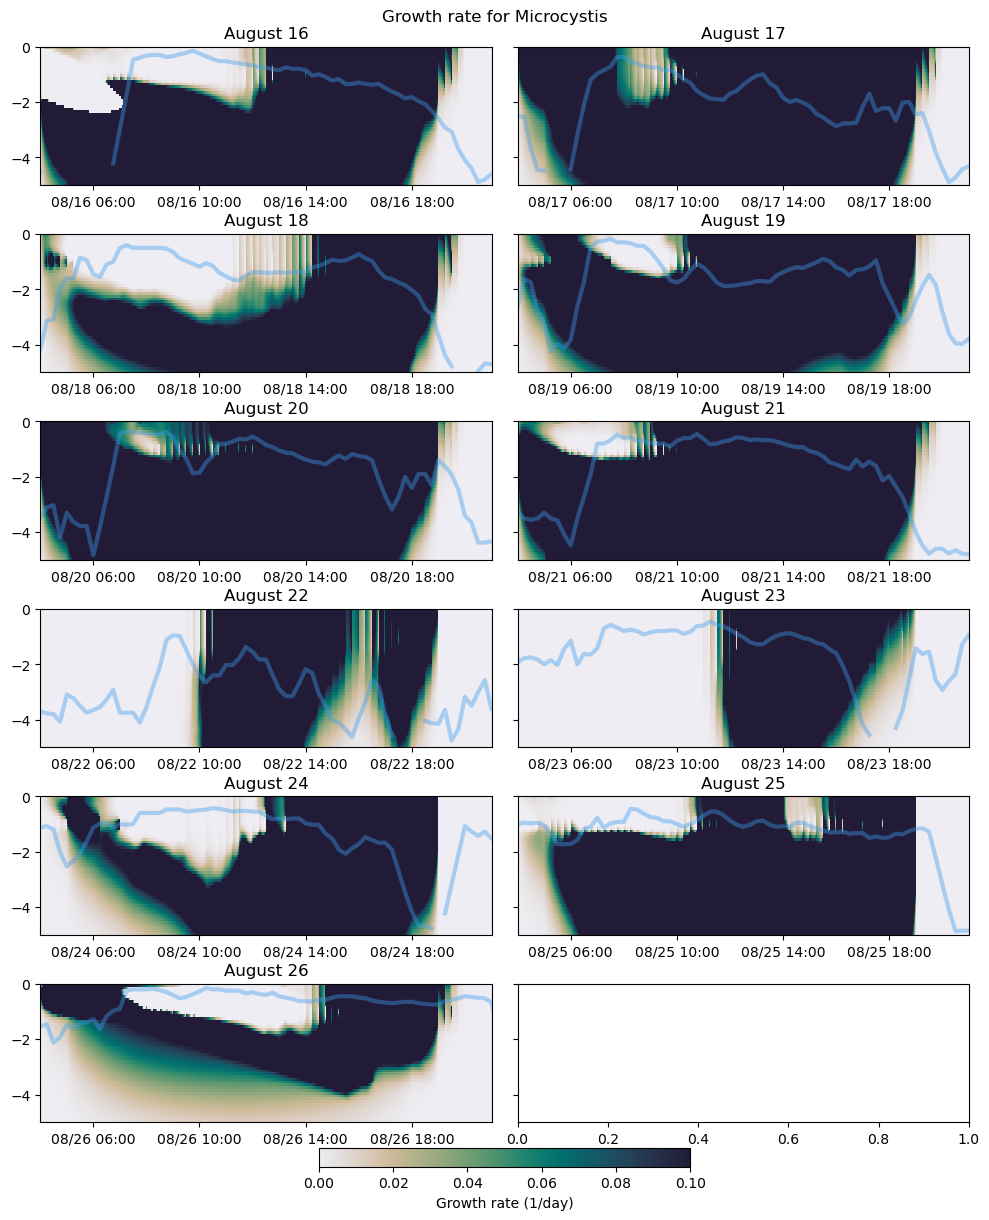

In [4]:
fig, axs = plt.subplots(nrows=6, ncols=2, figsize=(10, 14), sharex=False, sharey=True)
axs = axs.flatten()


for i,d in enumerate(range(16,27)):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    axs[i].plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.4, color="#3C9FF0") 
    h = axs[i].pcolormesh(time, -z, ds.gamma1.values.T*(86400), cmap=cmo.cm.rain, vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    axs[i].set_ylim(-5, 0)
    format_date_ax(axs[i])
    axs[i].set_xlim(time[0], time[-1])
    axs[i].set_title("August %d" % d)
    fig.suptitle("Growth rate for Microcystis")

plt.tight_layout()
fig.colorbar(h, ax=axs, orientation='horizontal', label='Growth rate (1/day)', shrink=0.4, pad=2e-2)






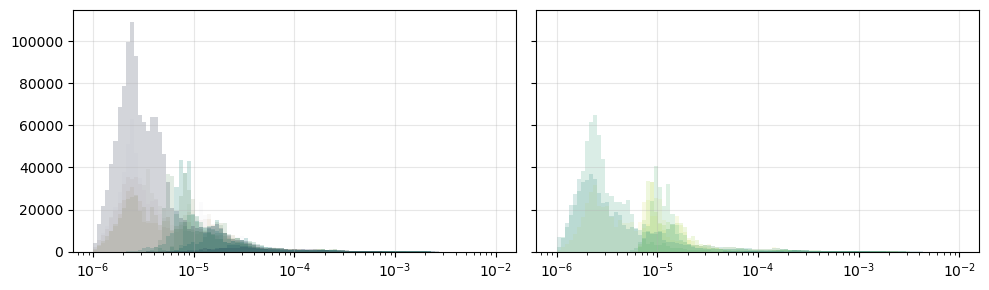

In [5]:
# NSCM  -- near surface chla max
NSCM = [6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26] #, 27]
# SSCM -- subsurface chla max

NSCM = [ 13, 14, 15, 17, 19, 20, 21, 22, 23] #, 27]
SSCM = [6, 7, 8, 9, 10, 11, 12, 16, 18, 24, 25, 26]

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), sharex=True, sharey=True)
axs = axs.flatten()

logbins = np.logspace(-6, -2, 100)

for i,d in enumerate(SSCM):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    hydro0 = hydro.Kz.isel(time=ds.t.values).values.flatten()
    axs[0].hist(hydro0, bins=logbins, density=True, color=cmo.cm.rain(i/len(SSCM)), alpha=0.2, label="Aug %d" % d)

for i,d in enumerate(NSCM):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    hydro0 = hydro.Kz.isel(time=ds.t.values).values.flatten()
    axs[1].hist(hydro0, bins=logbins, density=True, color=cmo.cm.haline_r(i/len(SSCM)), alpha=0.2, label="Aug %d" % d)


axs[0].grid(alpha=0.3)
axs[1].grid(alpha=0.3)
axs[0].set_xscale('log')
axs[1].set_xscale('log')


plt.tight_layout()


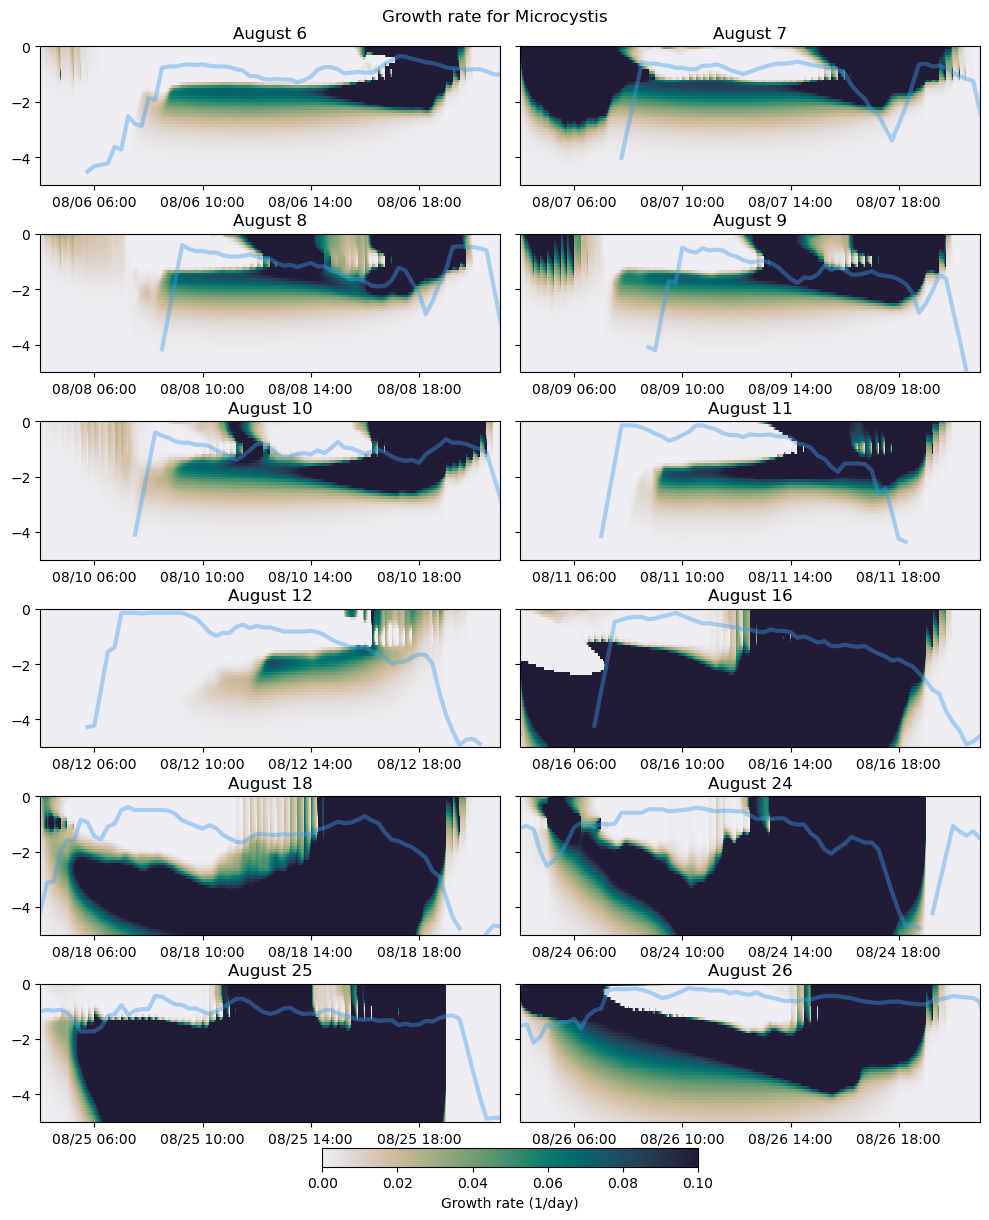

In [6]:

fig, axs = plt.subplots(nrows=6, ncols=2, figsize=(10, 14), sharex=False, sharey=True)
axs = axs.flatten()

for i,d in enumerate(SSCM):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    axs[i].plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.4, color="#3C9FF0") 
    h = axs[i].pcolormesh(time, -z, ds.gamma1.values.T*(86400), cmap=cmo.cm.rain, vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    axs[i].set_ylim(-5, 0)
    format_date_ax(axs[i])
    axs[i].set_xlim(time[0], time[-1])
    axs[i].set_title("August %d" % d)
    fig.suptitle("Growth rate for Microcystis")

plt.tight_layout()
fig.colorbar(h, ax=axs, orientation='horizontal', label='Growth rate (1/day)', shrink=0.4, pad=2e-2)


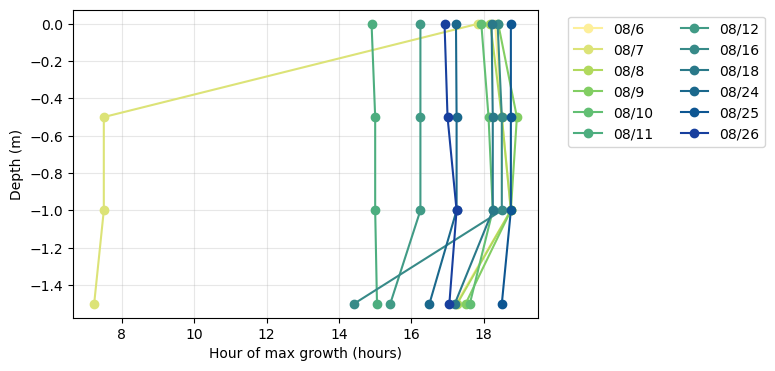

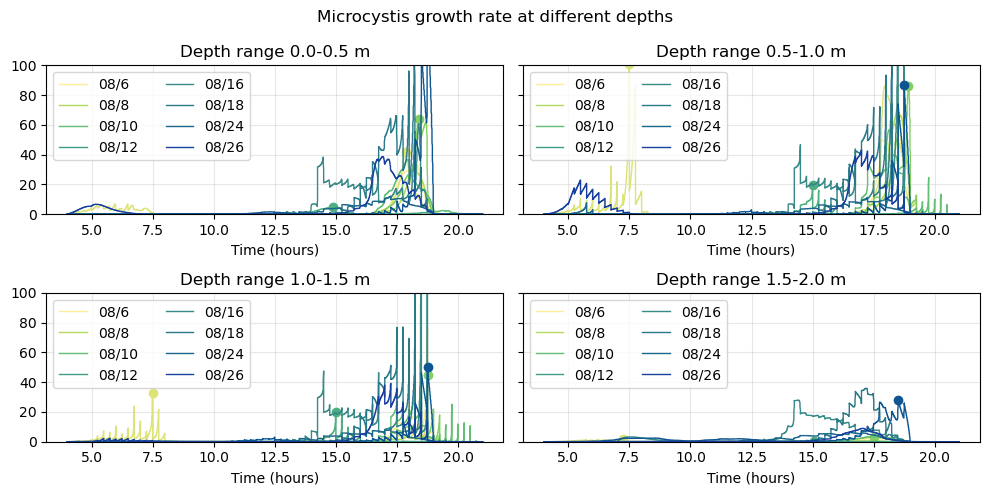

In [7]:
# characterize growth at depths 


fig2 = plt.figure(figsize=(6, 4))
ax2 = fig2.add_subplot(111)

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 5), sharex=False, sharey=True)
axs = axs.flatten()

# ax2 = []
# for ax in axs:
#     ax2_ = ax.twinx()
#     ax2.append(ax2_)
#     ax2_.set_yscale('log')
        
# hydro01 = hydro0.sel(z=slice(zmin+2, zmax)).mean(dim='z')
# print(hydro01)
# ax2[ia].plot(t0, hydro01.Kz.values, '-', color=cmo.cm.haline_r(i/13), alpha=0.5)
zs = [(0.5, 0), (1, 0.5), (1.5, 1), (2, 1.5)] #, (3, 2)] #, (4.5, 4), (5, 4.5), (5.5, 5), (6, 5.5)]



for i,d in enumerate(SSCM):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    t0 = [t.hour + t.minute/60 for t in time]
    hydro0 = hydro.isel(time=ds.t.values)
    # axs[i].plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.4, color="#3C9FF0") 

    tmax = [] 
    zavg = [] 

    for ia, (zmin, zmax) in enumerate(zs):


        growth0 = ds.gamma1.sel(z=slice(zmin, zmax)).mean(dim='z') *(86400)
        max0 = np.argmax(growth0.values)
        # growth0 = growth0.rolling(t=60, center=True).mean()
    
        if d%2 == 0:
            axs[ia].plot(t0, growth0, linewidth=1, color=cmo.cm.haline_r(i/13), label="08/%d" % (d)) #, label="%.1f-%.1fm
        else:
            axs[ia].plot(t0, growth0, linewidth=1, color=cmo.cm.haline_r(i/13)) #, label="%.1f-%.1fm
            axs[ia].plot(t0[max0], growth0[max0], 'o', color=cmo.cm.haline_r(i/13)) #, label="%.1f-%.1fm

        axs[ia].set_title("Depth range %.1f-%.1f m" % (zmax, zmin))
        # h = axs[i].pcolormesh(time, -z, ds.gamma1.values.T*(86400), cmap=cmo.cm.rain, vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
        axs[ia].set_ylim(0, 100)
        tmax.append(t0[max0])
        zavg.append(-zmax)

    ax2.plot(tmax, zavg,  '-o', color=cmo.cm.haline_r(i/13), label="08/%d" % (d))    

for ax in axs:
    # format_date_ax(ax)
    ax.legend(loc='upper left', ncols=2)
    # ax.set_xlim(time[400], time[-1])
    ax.grid(alpha=0.3)
    ax.set_ylim(0,)
    ax.set_xlabel("Time (hours)")
    # axs[i].set_title("August %d" % d)

plt.suptitle("Microcystis growth rate at different depths")
plt.tight_layout()

ax2.grid(alpha=0.3)
ax2.set_ylabel("Depth (m)")
ax2.set_xlabel("Hour of max growth (hours)")
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
# fig.colorbar(h, ax=axs, orientation='horizontal', label='Growth rate (1/day)', shrink=0.4, pad=2e-2)

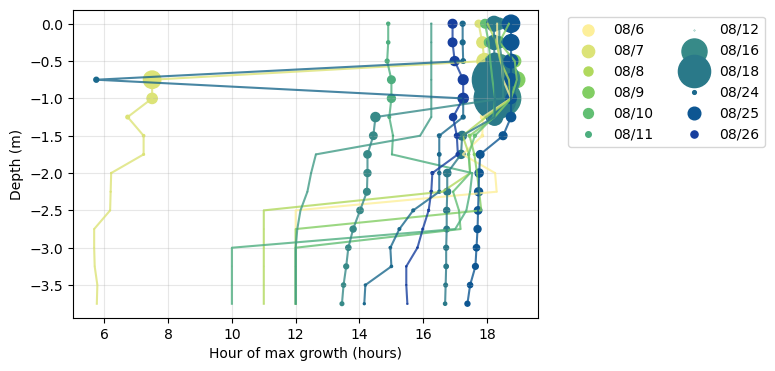

In [8]:
# characterize growth at depths 


fig2 = plt.figure(figsize=(6, 4))
ax2 = fig2.add_subplot(111)


STEP = 0.25
zs = np.arange(0, 4, step=STEP)


for i,d in enumerate(SSCM):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    t0 = [t.hour + t.minute/60 for t in time]
    hydro0 = hydro.isel(time=ds.t.values)
    # axs[i].plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.4, color="#3C9FF0") 

    tmax = [] 
    zavg = [] 
    growth= [] 

    for ia, zmax in enumerate(zs):
        zmin = zmax + STEP 
        
        growth0 = ds.gamma1.sel(z=slice(zmin, zmax)).mean(dim='z') *(86400)
        max0 = np.argmax(growth0.values)
        g = growth0[max0].values
        if g<0:
            growth.append(0) 
        else:
            growth.append(g) # growth0[max0].values)
        
        tmax.append(t0[max0])
        zavg.append(-zmax)

    ax2.plot(tmax, zavg, color=cmo.cm.haline_r(i/13), alpha=0.8)    
    ax2.scatter(tmax, zavg, s=growth,  color=cmo.cm.haline_r(i/13), label="08/%d" % (d))    

ax2.grid(alpha=0.3)
ax2.set_ylabel("Depth (m)")
ax2.set_xlabel("Hour of max growth (hours)")
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)


# 

NameError: name 'norm' is not defined

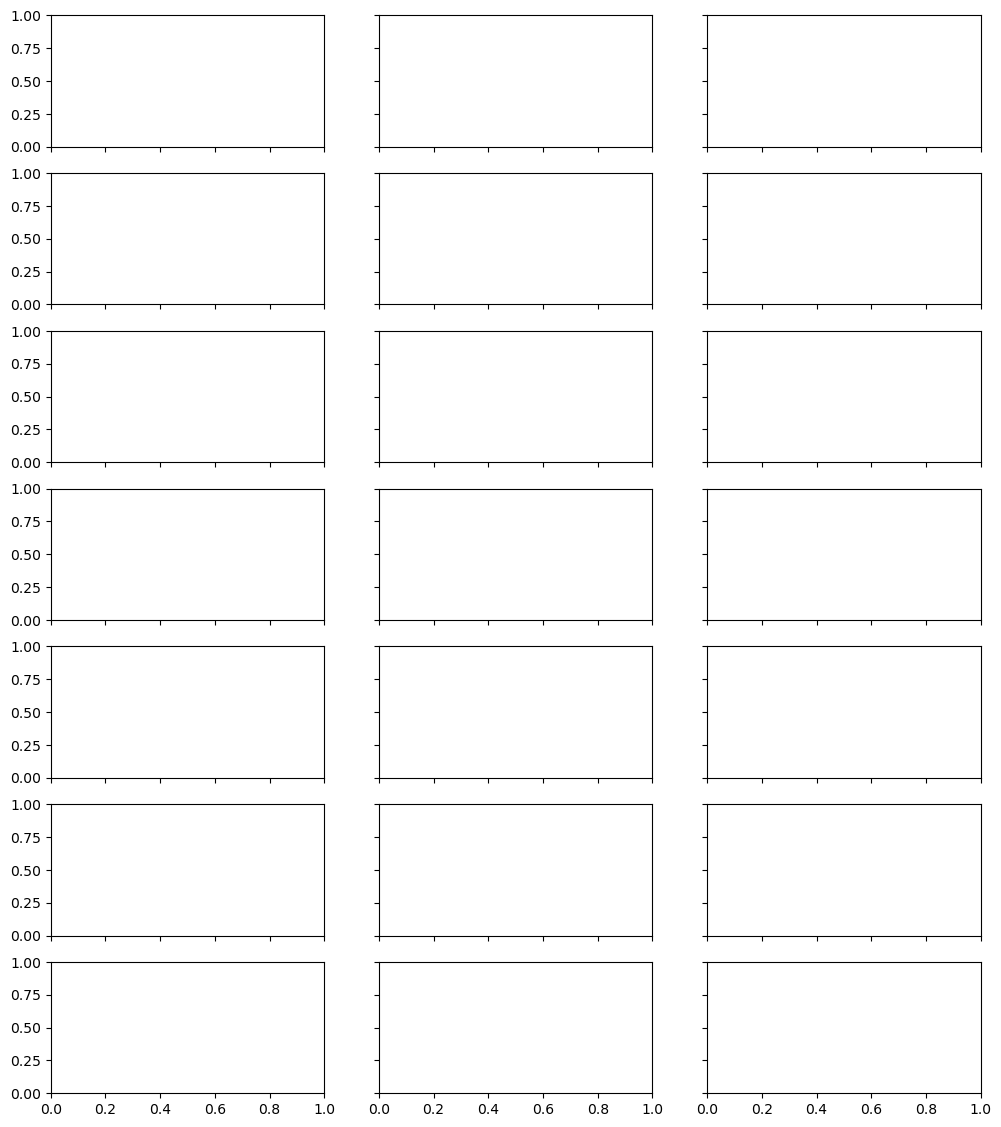

In [9]:
# Depth of max growth
fig, axs = plt.subplots(nrows=7, ncols=3, figsize=(12, 14), sharex=True, sharey=True)
axs = axs.flatten()

mixed_depth['day'] = mixed_depth['time'].dt.day
mixed_depth['hour'] = mixed_depth['time'].dt.hour + mixed_depth['time'].dt.minute/60

for i,d in enumerate(range(6,27)):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    t0 = [t.hour + t.minute/60 for t in time]
    growth0 = ds.gamma1.argmax(dim="z")
    depths = ds.gamma1.z.values[growth0]
    depths[depths==5.95] = np.nan


    hydro0 = hydro.isel(time=ds.t.values)
    h= axs[i].contourf(t0, -z, hydro0.Kz.values.T, cmap=cmo.cm.haline_r, levels=[1e-7,1e-6,1e-5,1e-4, 1e-3,  1e-2,1e-1], norm=norm, alpha=0.9) 
    mixed0 = mixed_depth.loc[mixed_depth.day == d]
    # axs[i].plot(mixed0['hour'], -mixed0["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=8, alpha=0.24, color="skyblue") #, color="#3C9
    # axs[i].fill_between(mixed0['hour'], -mixed0["Depth_MixedLayer_Max_60min_movavg"],y2=-4, alpha=0.24, color="skyblue") #, color="#3C9

    axs[i].plot(t0, -depths,'.', color='white') #cmo.cm.haline_r(i/20))
    axs[i].set_title("August %d" % d)
    axs[i].grid(alpha=0.3)
plt.colorbar(h)
axs[i].set_ylim(-5.5, 0)
axs[i].set_xlim(7, 20)

# 

IndexError: index 15 is out of bounds for axis 0 with size 15

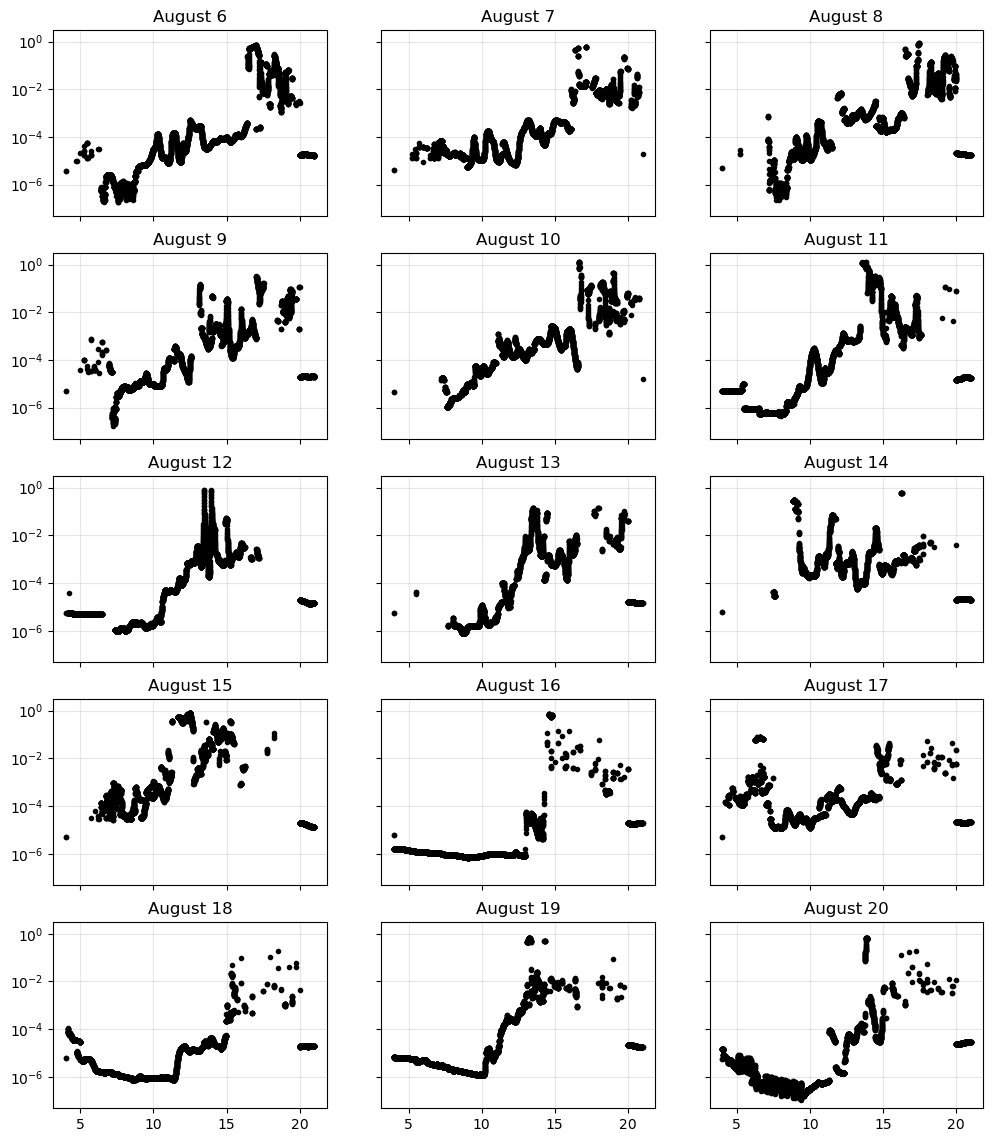

In [ ]:
# Depth of max growth
fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(12, 14), sharex=True, sharey=True)
axs = axs.flatten()


for i,d in enumerate(range(6,27)):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    hydro0 = hydro.isel(time=ds.t.values)

    t0 = [t.hour + t.minute/60 for t in time]
    growth0 = ds.gamma1.argmax(dim="z")
    depths = ds.gamma1.z.values[growth0]

    growth0 = growth0.values



    vals = [] 
    for ii, g0 in enumerate(growth0):
        if g0 == 59:
            val = np.nan
        else:
            val = hydro0.Kz.isel(z=g0, time=ii).values / depths[ii]**2 
        vals.append(val)

    axs[i].plot(t0, vals, '.', color='k') #cmo.cm.haline_r(i/20))
    axs[i].set_yscale('log')

#     mixed0 = mixed_depth.loc[mixed_depth.day == d]
#     # axs[i].plot(mixed0['hour'], -mixed0["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=8, alpha=0.24, color="skyblue") #, color="#3C9
#     # axs[i].fill_between(mixed0['hour'], -mixed0["Depth_MixedLayer_Max_60min_movavg"],y2=-4, alpha=0.24, color="skyblue") #, color="#3C9

#     axs[i].plot(t0, -depths,'.', color='white') #cmo.cm.haline_r(i/20))
    axs[i].set_title("August %d" % d)
    axs[i].grid(alpha=0.3)

# axs[i].set_ylim(-5.5, 0)
# axs[i].set_xlim(7, 20)

# 

In [ ]:
# fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(10, 14), sharex=False, sharey=True)
# axs = axs.flatten()

# mixed_depth0 = mixed_depth.set_index('time').drop_duplicates(how='first')
# print(mixed_depth0)

# for i,d in enumerate(range(6,16)):
#     ds = guess["%02d" % (d)]
#     time = Dates[ds.t.values]
#     axs[i].plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.4, color="#3C9FF0")
    

#     print(mixed_depth0.index.get_loc(time[0]))
#     # 
#     test = ds.gamma1.sel(z=slice(1,0)) #*(86400) 

#     print(test)
#     assert(False)
#     h = axs[i].pcolormesh(time, -z, ds.gamma1.values.T*(86400), cmap=cmo.cm.rain, vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
#     axs[i].set_ylim(-5, 0)
#     format_date_ax(axs[i])
#     axs[i].set_xlim(time[0], time[-1])
#     axs[i].set_title("August %d" % d)
#     fig.suptitle("Growth rate for Microcystis")

# plt.tight_layout()
# fig.colorbar(h, ax=axs, orientation='horizontal', label='Growth rate (1/day)', shrink=0.4, pad=2e-2)

NameError: name 'chla' is not defined

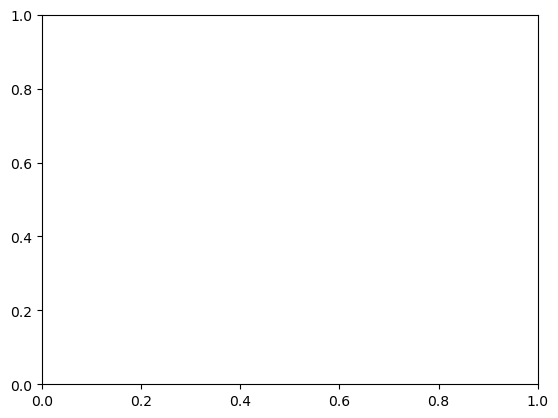

In [ ]:

fig = plt.figure() #(nrows=1, ncols=1, figsize=(10, 5), sharex=False, sharey=True)
ax = plt.gca() 
import matplotlib as mpl 
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)


for i,d in enumerate(range(6,16)):
    ds = guess["%02d" % (d)]

    time = Dates[ds.t.values]
    hydro0 = hydro.isel(time=ds.t.values)
    hydro0 = hydro0.sel(z=slice(4, 0))
    kz_ = hydro0.Kz.mean(dim="z")

    df = pd.DataFrame({'time': time, 'kz': kz_})
    df = df.set_index('time')
    df2 = pd.DataFrame(index=chla.time) 
    df2['chla'] = obs_roll.values
    df['chla'] = df2['chla']
    df.dropna(how='any', inplace=True)

    ax.plot(df['kz'], df['chla']*1e-3, 'o', color=cmo.cm.haline(i/10), alpha=0.8, label='August %d' % d)
    # correlation coefficent 
    r = np.corrcoef(df['kz'], df['chla'])[0,1]
    print(r)

# ax.set_ylim(2, 22)
ax.grid(True, which="both", alpha=0.2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncols=2)
ax.set_ylabel("Observed Chlorophyll-a (mg/m$^3$)")
ax.set_xlabel("Modeled Diffusivity (m$^2$/s)")
# plt.tight_layout()

0.40831711504677354
0.0399451642348279
0.6585566296346697
0.42718570946022233
0.4905300339437859
0.4472193396443182
-0.11080629162364433
0.5786743084183442
0.7669527519434857
0.4144748935350439


Text(0.5, 0, 'Temperature')

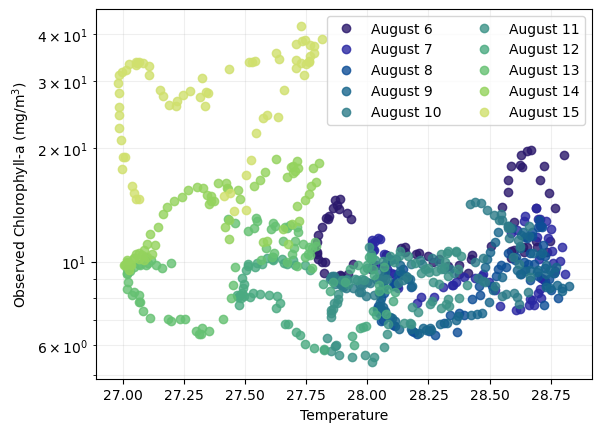

In [ ]:
# fig = plt.figure() #(nrows=1, ncols=1, figsize=(10, 5), sharex=False, sharey=True)
# ax = plt.gca() 
# import matplotlib as mpl 
# norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)


# for i,d in enumerate(range(6,16)):
#     ds = guess["%02d" % (d)]

#     time = Dates[ds.t.values]
#     hydro0 = hydro.isel(time=ds.t.values)
#     hydro0 = hydro0.sel(z=slice(3, 0))
#     T = hydro0.C.mean(dim="z")

#     df = pd.DataFrame({'time': time, 'T': T})
#     df = df.set_index('time')
#     df2 = pd.DataFrame(index=chla.time) 
#     df2['chla'] = obs_roll.values
#     df['chla'] = df2['chla']
#     df.dropna(how='any', inplace=True)

#     ax.plot(df['T'], df['chla']*1e-3, 'o', color=cmo.cm.haline(i/10), alpha=0.8, label='August %d' % d)
#     # correlation coefficent 
#     r = np.corrcoef(df['T'], df['chla'])[0,1]
#     print(r)

# # ax.set_ylim(2, 22)
# ax.grid(True, which="both", alpha=0.2)
# ax.set_yscale("log")
# ax.legend(ncols=2)
# ax.set_ylabel("Observed Chlorophyll-a (mg/m$^3$)")
# ax.set_xlabel("Temperature")


In [ ]:
# Chlorophyll-a data
chla = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/forcing_for_model/2024/august6-16/chla_for_adjoint.csv")
chla['time'] = pd.to_datetime(chla['time'])
obs = chla.pg_chla_perML 

# Rolling average to smooth the data
obs_roll = obs.rolling(window=10, center=True).mean()
chla['obs_roll'] = obs_roll

In [ ]:
# %history

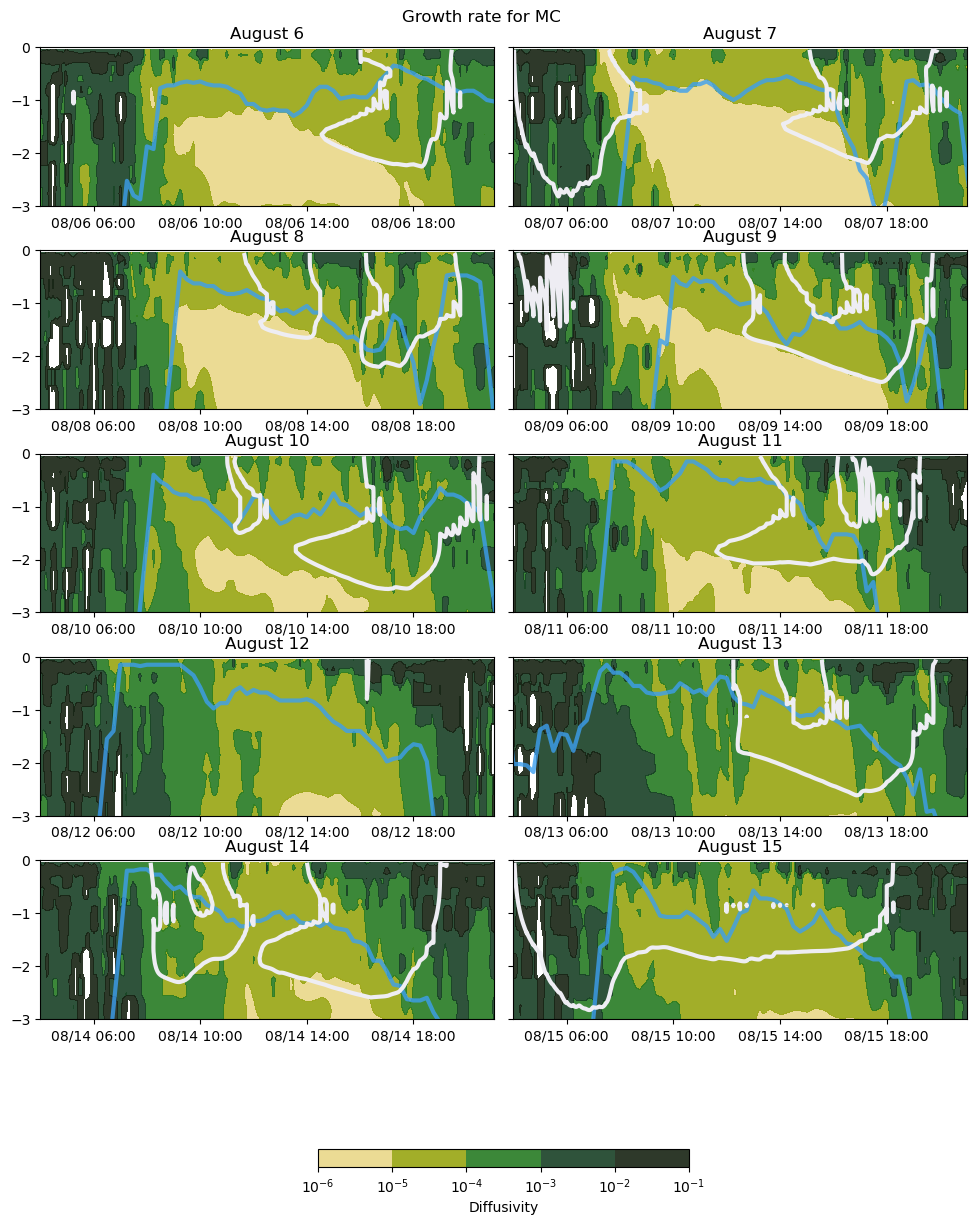

In [ ]:
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(10, 14), sharex=False, sharey=True)
axs = axs.flatten()

import matplotlib as mpl 
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)
for i,d in enumerate(range(6,16)):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    hydro0 = hydro.isel(time=ds.t.values)
    h= axs[i].contourf(time, -z, hydro0.Kz.values.T, cmap=cmo.cm.speed, levels=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1], norm=norm, alpha=0.9) 
    axs[i].plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.8, color="#3C9FF0") 

    axs[i].contour(time, -z, ds.gamma1.values.T*(86400), cmap=cmo.cm.rain, levels=[1e-1], linewidths=3 )#vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    axs[i].set_ylim(-3, 0)
    axs[i].set_xlim(time[0], time[-1])
    format_date_ax(axs[i])
    axs[i].set_title("August %d" % d)
    fig.suptitle("Growth rate for MC")

plt.tight_layout()
fig.colorbar(h, ax=axs, orientation='horizontal', label='Diffusivity', shrink=0.4, pad=1e-1)

<>:25: SyntaxWarning: invalid escape sequence '\k'
<>:25: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_1372542/1104762943.py:25: SyntaxWarning: invalid escape sequence '\k'
  axs[i].set_ylabel("$\kappa$ (m$^2$/s)")


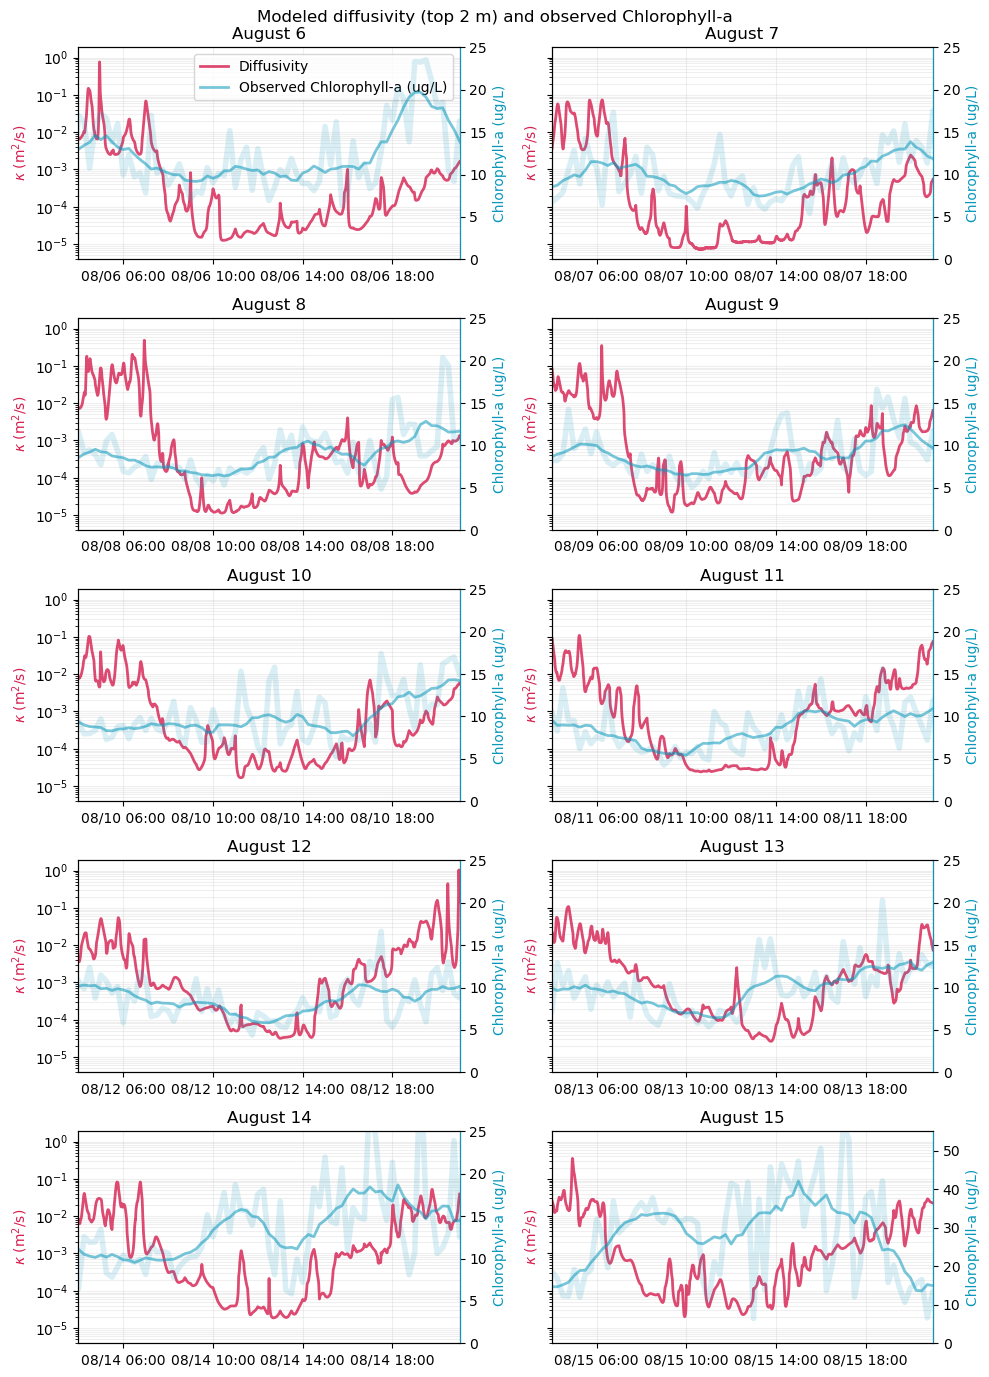

In [ ]:
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(10, 14), sharex=False, sharey=True)
axs = axs.flatten()

import matplotlib as mpl 
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)
for i,d in enumerate(range(6,16)):
    ds = guess["%02d" % (d)]

    time = Dates[ds.t.values]
    hydro0 = hydro.isel(time=ds.t.values)
    hydro0 = hydro0.sel(z=slice(2, 0))
    kz_ = hydro0.Kz.mean(dim="z")

    h= axs[i].plot(time, kz_, color="#D61E4F", linewidth=2, alpha=0.8, label='Diffusivity')
    ax2= axs[i].twinx()
    ax2.plot(chla.time, obs*1e-3, color="#0998BC", alpha=0.15, linewidth=4, label='Smoothed observed Chlorophyll-a (ug/L)')
    ax2.plot(chla.time, obs_roll*1e-3, color="#0998BC", alpha=0.55, linewidth=2, label='Observed Chlorophyll-a (ug/L)')
    ax2.set_ylim(0,25)
    #Change color of axis
    ax2.set_ylabel("Chlorophyll-a (ug/L)")
    ax2.spines['right'].set_color("#0998BC")
    ax2.yaxis.label.set_color("#0998BC")
    axs[i].set_yscale("log")
    axs[i].grid(True, which="both", alpha=0.2)
    axs[i].set_ylabel("$\kappa$ (m$^2$/s)")
    axs[i].yaxis.label.set_color("#D61E4F")
    # axs[i].plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.8, color="#3C9FF0") 

    # axs[i].contour(time, -z, ds.gamma1.values.T*(86400), cmap=cmo.cm.rain, levels=[1e-1], linewidths=3 )#vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    # axs[i].set_ylim(-3, 0)
    axs[i].set_xlim(time[0], time[-1])
    format_date_ax(axs[i])
    axs[i].set_title("August %d" % d)
    fig.suptitle("Modeled diffusivity (top 2 m) and observed Chlorophyll-a")
ax2.set_ylim(0, 55)
axs[0].plot([], [], color="#0998BC", alpha=0.55, linewidth=2, label='Observed Chlorophyll-a (ug/L)')

axs[0].legend() 
plt.tight_layout()


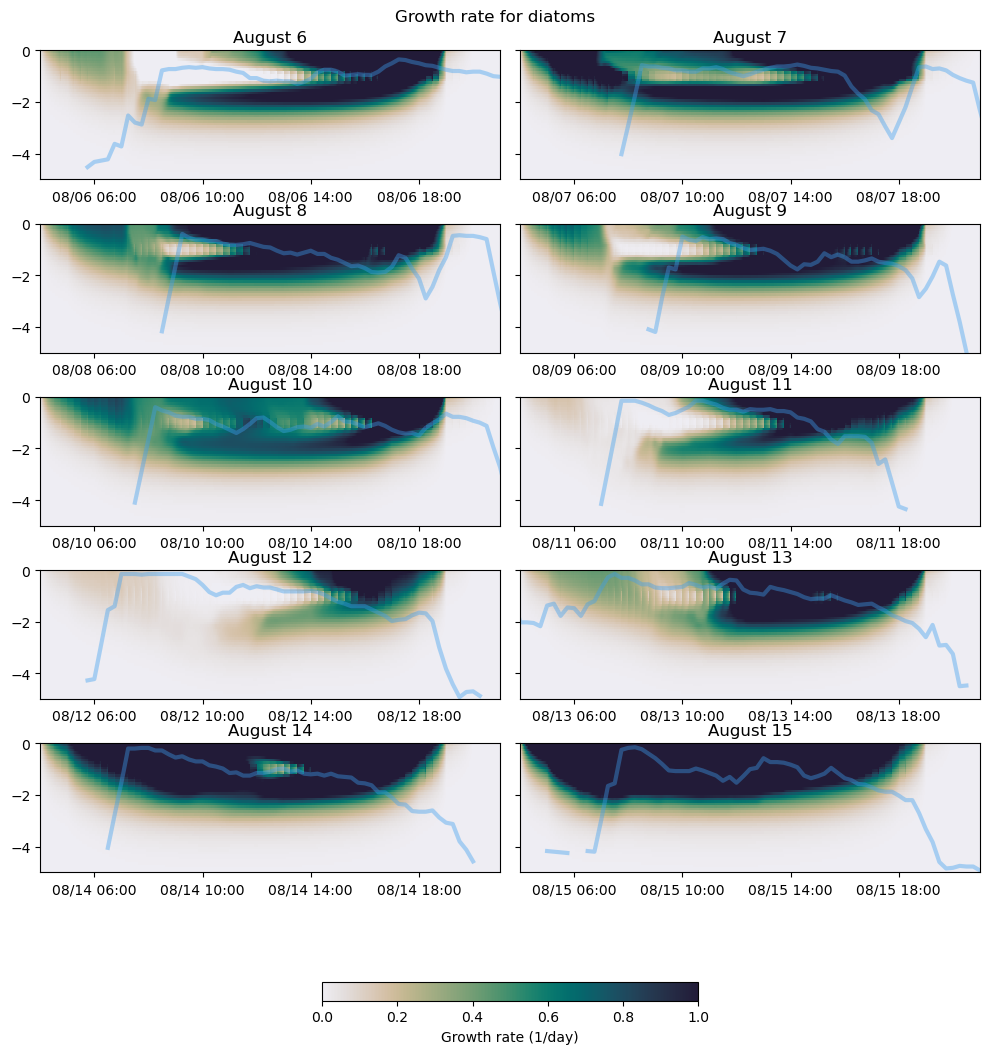

In [ ]:
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(10, 12), sharex=False, sharey=True)
axs = axs.flatten()

for i,d in enumerate(range(6,16)):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    axs[i].plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.4, color="#3C9FF0") 
    axs[i].set_xlim(time[0], time[-1])

    h = axs[i].pcolormesh(time, -z, ds.gamma2.values.T*(86400), cmap=cmo.cm.rain, vmin=0, vmax=1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    axs[i].set_ylim(-5, 0)
    format_date_ax(axs[i])
    axs[i].set_title("August %d" % d)
    fig.suptitle("Growth rate for diatoms")

plt.tight_layout()
fig.colorbar(h, ax=axs, orientation='horizontal', label='Growth rate (1/day)', shrink=0.4, pad=2e-2)

Index(['TIMESTAMP', 'DEPTH', 'TEMPERATURE', 'DENSITY', 'SITE',
       'Dens_Average_MixedCond', 'Dens_Min', 'Dens_Max', 'Dens_MaxDiff',
       'Temp_Average_MixedCond', 'Temp_Min', 'Temp_Max', 'Temp_MaxDiff',
       'PE_Anomaly (J/m^2)', 'dPEA_dt (J/m^2)', 'PE_Anomaly (J/m^3)',
       'dPEA_dt (J/m^3)', 'dpavg_dt', 'N_squared', 'dp_dz', 'TimeofDay',
       'Interval', 'dp_dz_Max', 'Depth_MixedLayer', 'RRI_WaterLevel',
       'Depth_MixedLayer_Max', 'Depth_MixedLayer_Min',
       'Depth_MixedLayer_Max_60min_movavg',
       'Depth_MixedLayer_Min_60min_movavg'],
      dtype='object')
Index(['TIMESTAMP', 'DEPTH', 'TEMPERATURE', 'DENSITY', 'SITE',
       'Dens_Average_MixedCond', 'Dens_Min', 'Dens_Max', 'Dens_MaxDiff',
       'Temp_Average_MixedCond', 'Temp_Min', 'Temp_Max', 'Temp_MaxDiff',
       'PE_Anomaly (J/m^2)', 'dPEA_dt (J/m^2)', 'PE_Anomaly (J/m^3)',
       'dPEA_dt (J/m^3)', 'dpavg_dt', 'N_squared', 'dp_dz', 'TimeofDay',
       'Interval', 'dp_dz_Max', 'Depth_MixedLayer', 'RRI_Wat

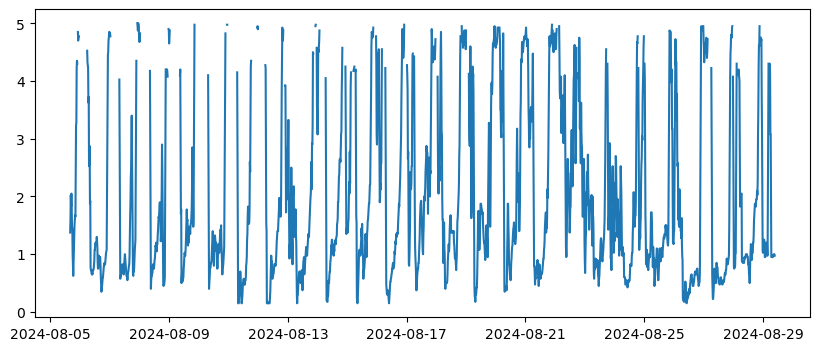

In [ ]:
mixed_depth = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/mixed_layer/TempDens_parametersbydepth.csv")
mixed_depth = mixed_depth.loc[mixed_depth.SITE == "WEB"]
mixed_depth['time'] = pd.to_datetime(mixed_depth['TIMESTAMP'])
mixed_depth.loc[mixed_depth["Depth_MixedLayer_Max_60min_movavg"] > 5] = np.nan
# print(mixed_depth.columns)

# print(mixed_depth["Depth_MixedLayer_Max_60min_movavg"])

# fig = plt.figure(figsize=(10, 4))
# plt.plot(mixed_depth['time'], mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-') 

on day 6


NameError: name 'obs' is not defined

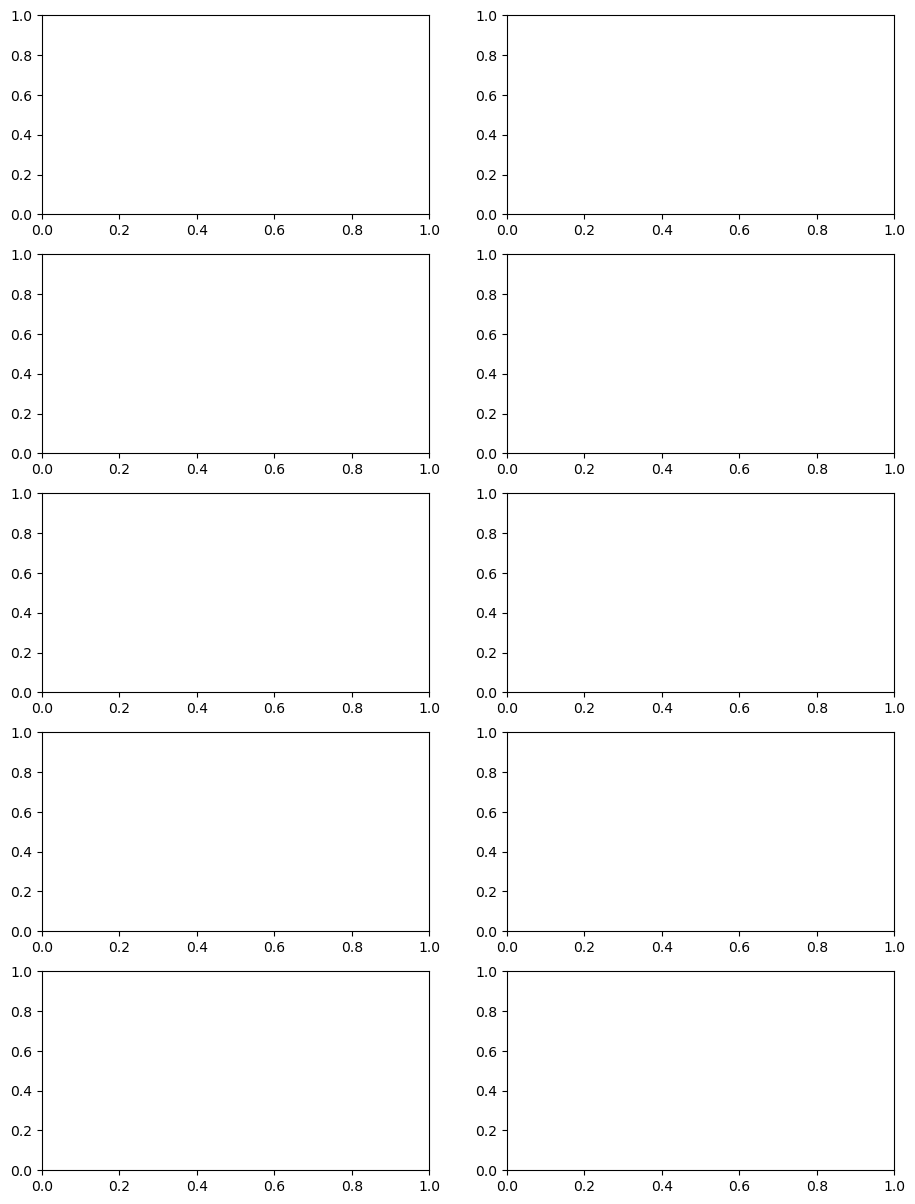

In [ ]:
chla2cell_mc =  1e-6/0.36  # ug chl-a/ml --> pg chl-a/ml --> 0.36  pg chl-a/cell Microcystis
chla2cell_diatom = 1e-6/4 # ug chl-a/ml --> pg chl-a/ml --> 4 pg chl-a/cell Diatom
cell2chla_mc = 1/chla2cell_mc
cell2chla_diatom = 1/chla2cell_diatom



fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(11, 15), sharex=False, sharey=False)
axs = axs.flatten()

for i,d in enumerate(range(6,16)):
    ds = guess["%02d" % (d)]
    print("on day", d)
    time = Dates[ds.t.values]
    axs[i].plot(chla.time, obs*1e-3, color="#0998BC", alpha=0.15, linewidth=4, label='Smoothed observed Chlorophyll-a (ug/L)')
    axs[i].plot(chla.time, obs_roll*1e-3, color="#0998BC", alpha=0.85, linewidth=2, label='Observed Chlorophyll-a (ug/L)')
    for iz in range(48,53):
        one_meter_data_N = ds.isel(z=iz)
        total = one_meter_data_N['algae1'].values.T*cell2chla_mc + one_meter_data_N['algae2'].values.T*cell2chla_diatom
        total[-1] = total[-2]
        axs[i].plot(time, total*1e-3, '-',  color='#A6BC09', linewidth=2, alpha=0.27)
    format_date_ax(axs[i])
    axs[i].set_xlim(time[0], time[-1])
    axs[i].set_ylim(3, 22)
    axs[i].grid(alpha=0.3)
    axs[i].set_title("August %d, 2024" % d)
    axs[i].set_ylabel("Algae biomass (ug/L)")

axs[0].legend()

axs[-1].set_ylim(0,55)
plt.tight_layout()

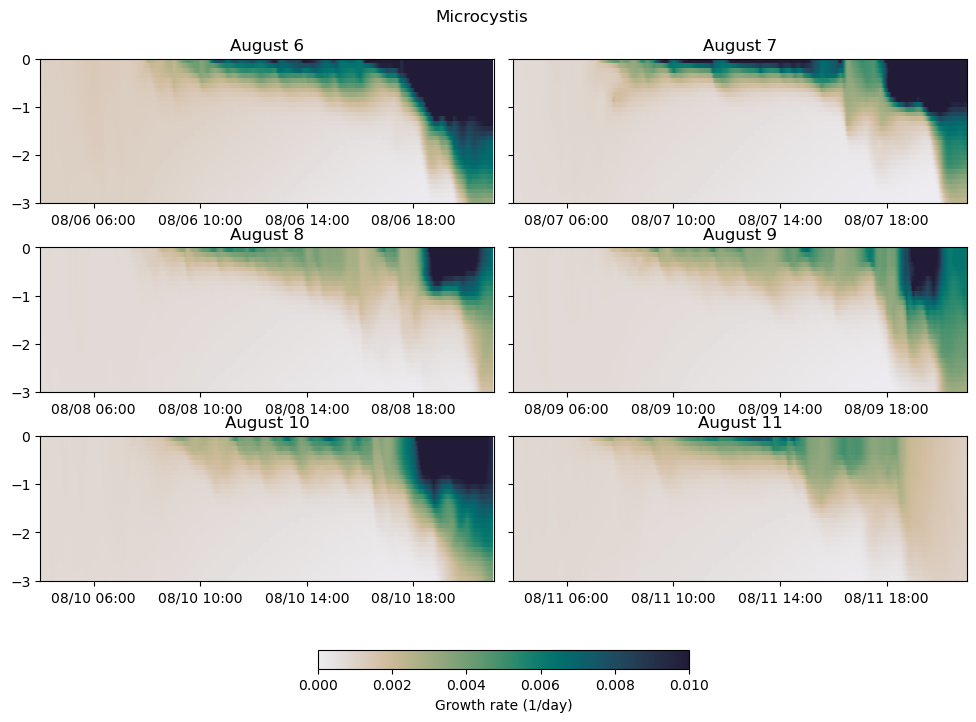

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 8), sharex=False, sharey=True)
axs = axs.flatten()

for i,d in enumerate(range(6,12)):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    h = axs[i].pcolormesh(time, -z, ds.algae1.values.T, cmap=cmo.cm.rain, vmin=0, vmax=1e-2)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    axs[i].set_ylim(-3, 0)
    format_date_ax(axs[i])
    axs[i].set_title("August %d" % d)
    fig.suptitle("Microcystis")

plt.tight_layout()
fig.colorbar(h, ax=axs, orientation='horizontal', label='Growth rate (1/day)', shrink=0.4, pad=1e-1)

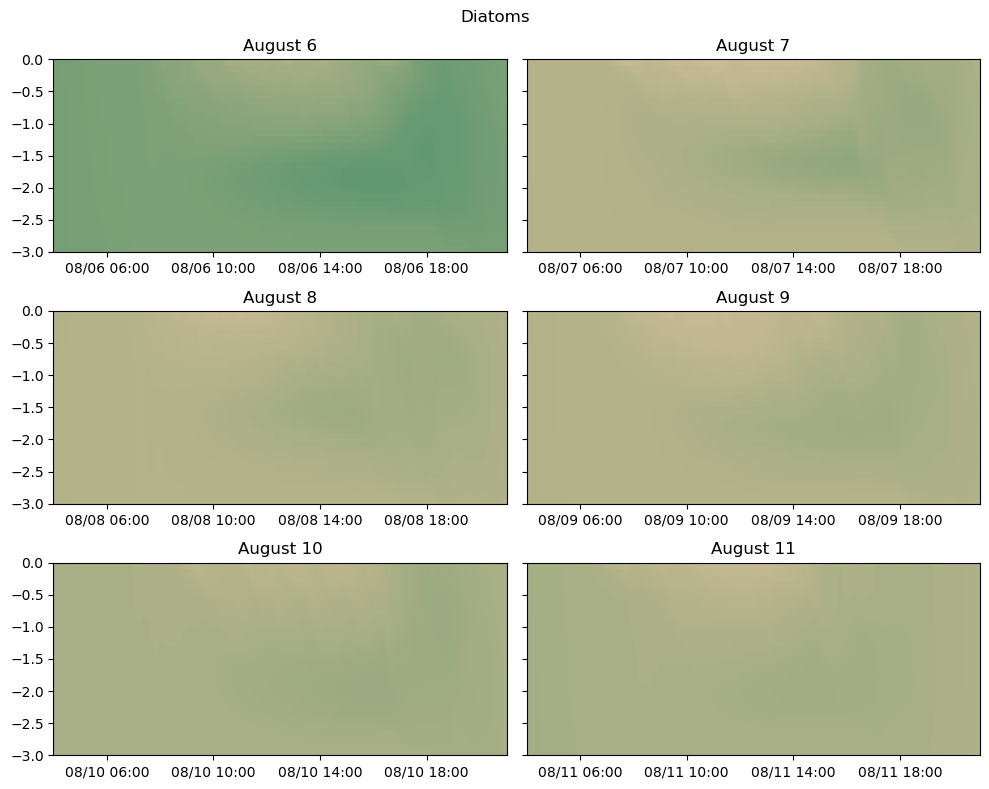

In [ ]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(10, 8), sharex=False, sharey=True)
axs = axs.flatten()

for i,d in enumerate(range(6,12)):
    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]
    h = axs[i].pcolormesh(time, -z, ds.algae2.values.T, cmap=cmo.cm.rain, vmin=0, vmax=8e-3)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
    axs[i].set_ylim(-3, 0)
    format_date_ax(axs[i])
    axs[i].set_title("August %d" % d)
    fig.suptitle("Diatoms")

plt.tight_layout()
# fig.colorbar(h, ax=axs, orientation='horizontal', label='Growth rate (1/day)', shrink=0.4, pad=1e-1)

In [ ]:
zscales = pd.read_csv("/global/homes/s/siennaw/scratch/siennaw/stockton_field_data/mixed_layer/Diffusivity_zscales.csv")
zscales['time'] = pd.to_datetime(zscales.timestamp_round15) 
zscales['photic'] = zscales["z_mixed_60minmovavg_sd"]
zscales = zscales.loc[zscales.site == "WEB"]
zscales.drop(columns=['site', 'date', 'microctd_timestamp', 'timestamp_round15'], inplace=True)
print(zscales.columns)


Index(['z_mixed_60minmovavg_masked', 'z_mixed_60minmovavg_max',
       'z_mixed_60minmovavg_sd', 'z_eu_site_avg', 'z_eu_site_sd',
       'z_eu_overall_avg', 'z_eu_overall_sd', 'z_eu_sitevisit_avg', 'time',
       'photic'],
      dtype='object')


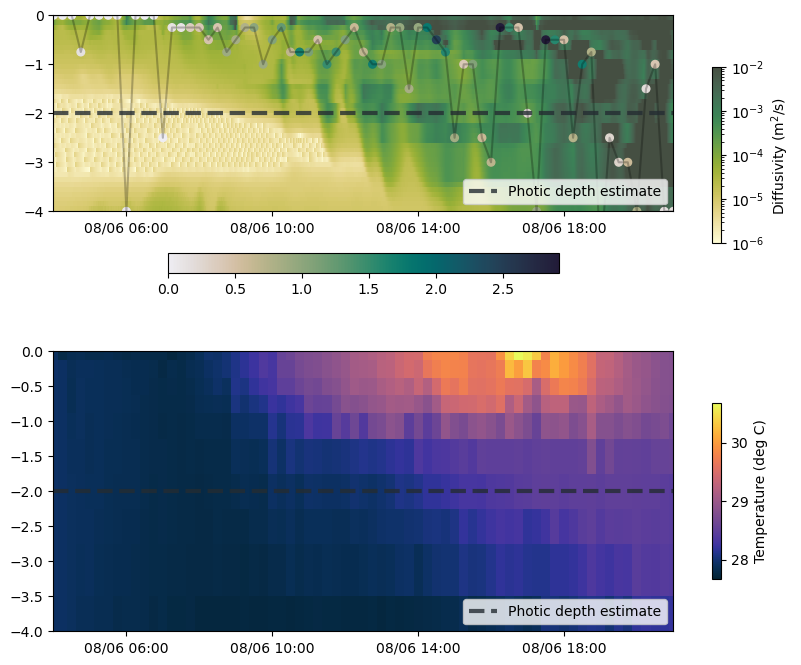

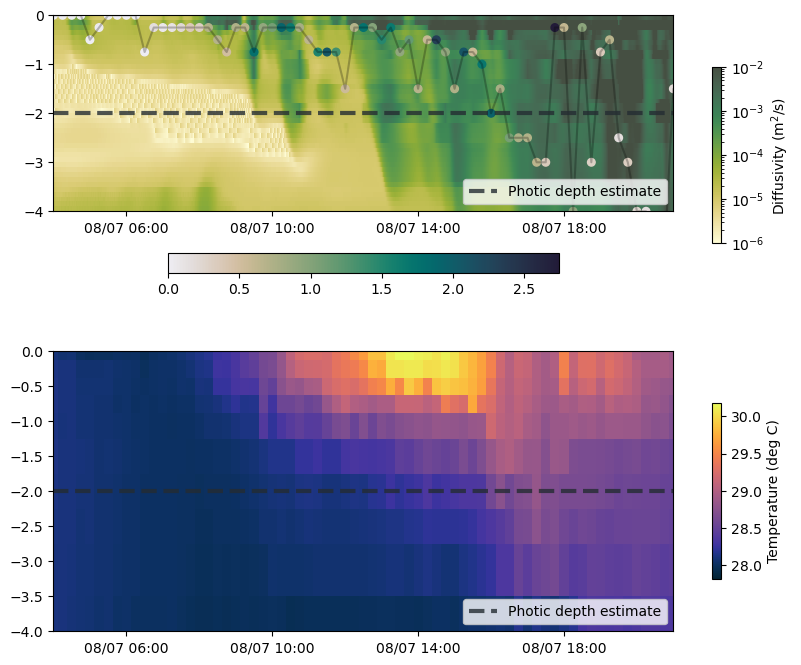

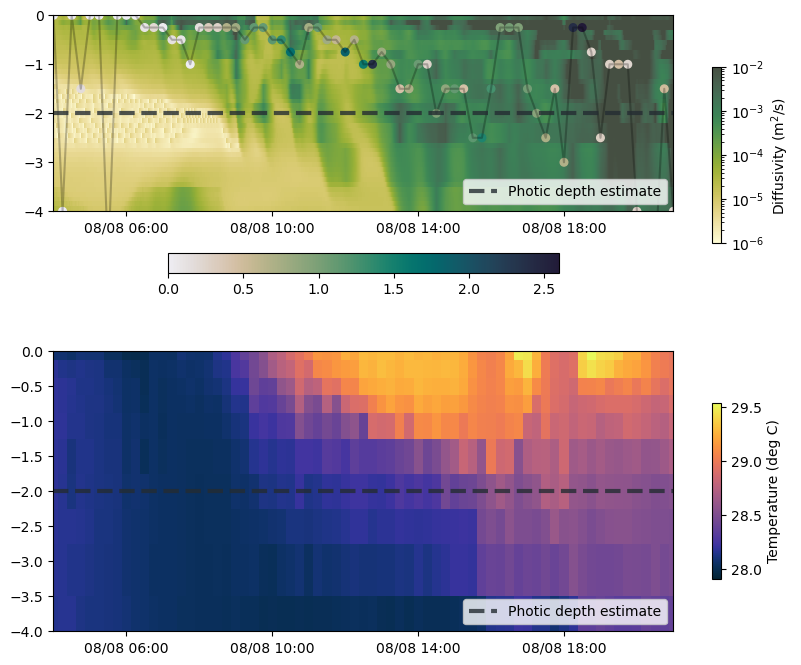

In [69]:
d = 6
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

for d in range(6, 9): 
    temp0 = temp.loc[temp.day == d]

    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    # plt.tight_layout()
    # fig.colorbar(h, ax=axs, orientation='horizontal', label='Diffusivity', shrink=0.4, pad=1e-1)

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10,8))
    # print(np.min(Z))
    # print(np.max(Z))

    hydro0 = hydro.isel(time=ds.t.values)
    a = axs[0].pcolormesh(time, -z, hydro0.Kz.values.T, cmap=cmo.cm.speed,  norm=norm, alpha=0.8)#, levels=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],) 
    plt.colorbar(a, ax=axs[0], label='Diffusivity (m$^2$/s)', orientation='vertical', shrink = 0.63) 
    # axs[0].contour(X, -Y, Z, cmap=cmo.cm.thermal, vmin=26, vmax=29)

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    # dT[dT<0.2] = np.nan
    # print(np.nanmax(dT, axis=1))
    mixed_d = np.argmax(dT, axis=0)
    # print(mixed_d)
    md = np.array([Y[i] for i in mixed_d])

    maxs = np.nanmax(dT, axis=0)


    
    # dT_ = np.array([dT[i, mixed_d[i]] for i in range(len(mixed_d))])
    # md[md==0] = np.nan
    axs[0].plot(X, -md,"-k", alpha=0.25) #, color='k', linewidth=3, alpha=0.8, label='Max dT/dz')
    c = axs[0].scatter(X, -md, c=maxs, s=30, cmap=cmo.cm.rain) #, color='k', linewidth=3, alpha=0.8, label='Max dT/dz')
    b = axs[1].pcolormesh(X, -Y, Z, cmap=cmo.cm.thermal) #, vmin=26, vmax=29)
    plt.colorbar(b, ax=axs[1], label='Temperature (deg C)', orientation='vertical', shrink = 0.63) 
    plt.colorbar(c, ax=axs[0],  orientation='horizontal', shrink = 0.63) 

    for ax in axs: 
        # h = ax.contour(time, -z, ds.gamma2.values.T*(86400), cmap=cmo.cm.rain, levels=[0.5, 1, 2], linewidths=3, label="Microcystis growth contour" )#vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
        plt.clabel(h, inline=1, fontsize=10)
        # ax.plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=4, alpha=0.8, color="#3C9FF0", label='Mixed layer depth') 
        ax.hlines(-2, time[0], time[-1], linestyles='--', color="#242C32", linewidth=3, alpha=0.8, label='Photic depth estimate')
        ax.set_xlim(time[0], time[-1])
        format_date_ax(ax)
        ax.legend( loc='lower right')
        ax.set_ylim(-4,0)

/tmp/ipykernel_409908/143943401.py:55: UserWarning: The following kwargs were not used by contour: 'label'
  h = ax.contour(time, -z, ds.gamma2.values.T*(86400), cmap=cmo.cm.rain, levels=[0.5, 1, 2], linewidths=3, label="Microcystis growth contour" )#vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)
/tmp/ipykernel_409908/143943401.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend( loc='lower right')


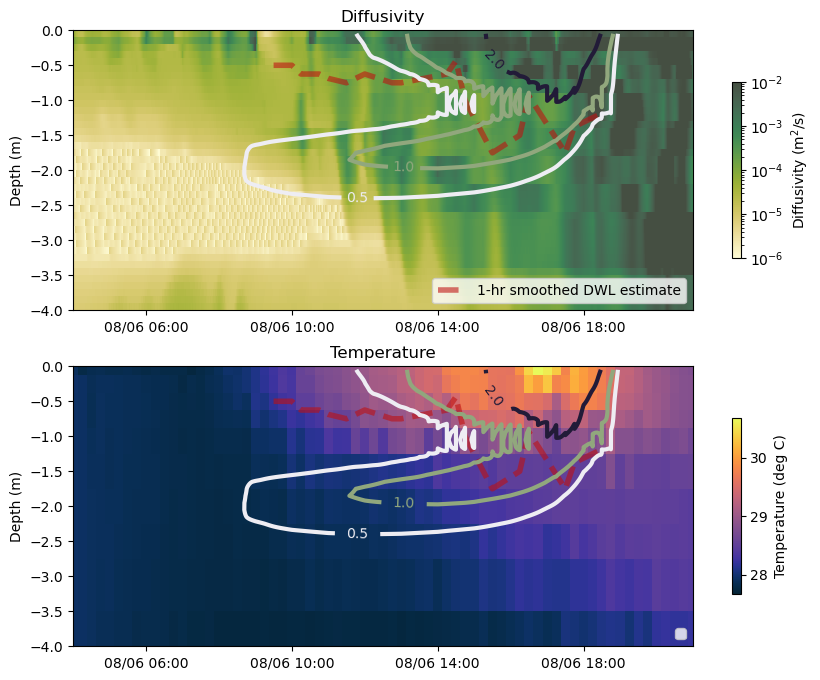

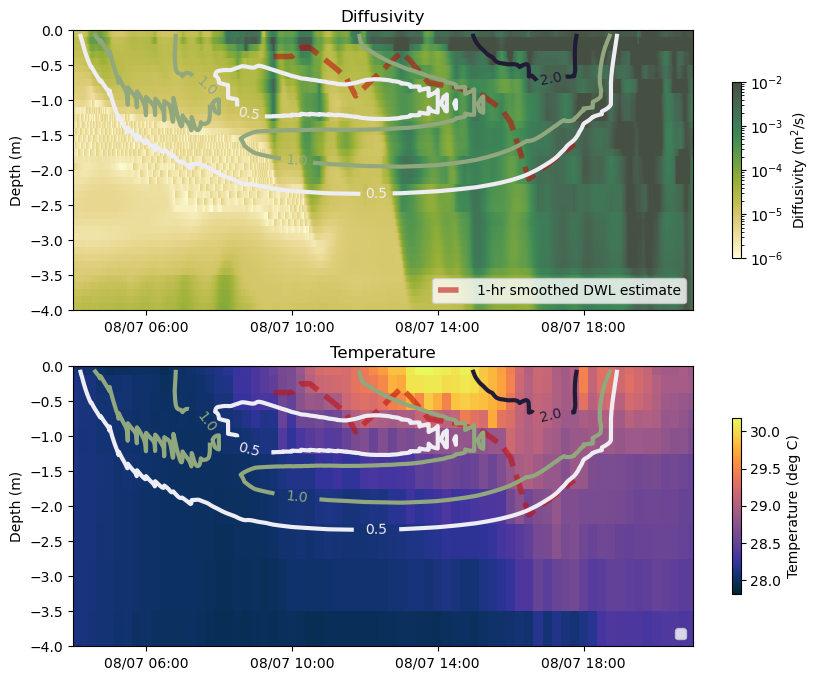

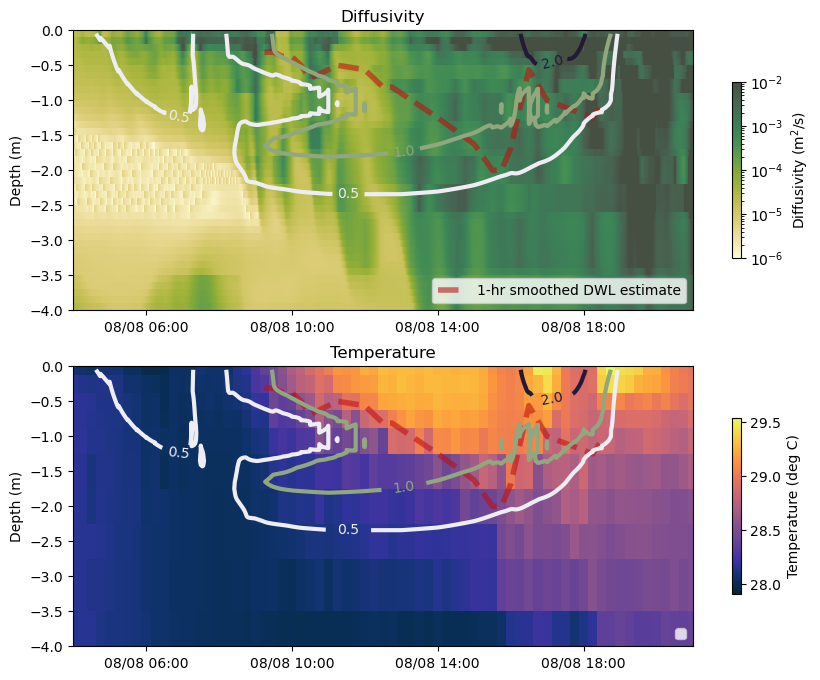

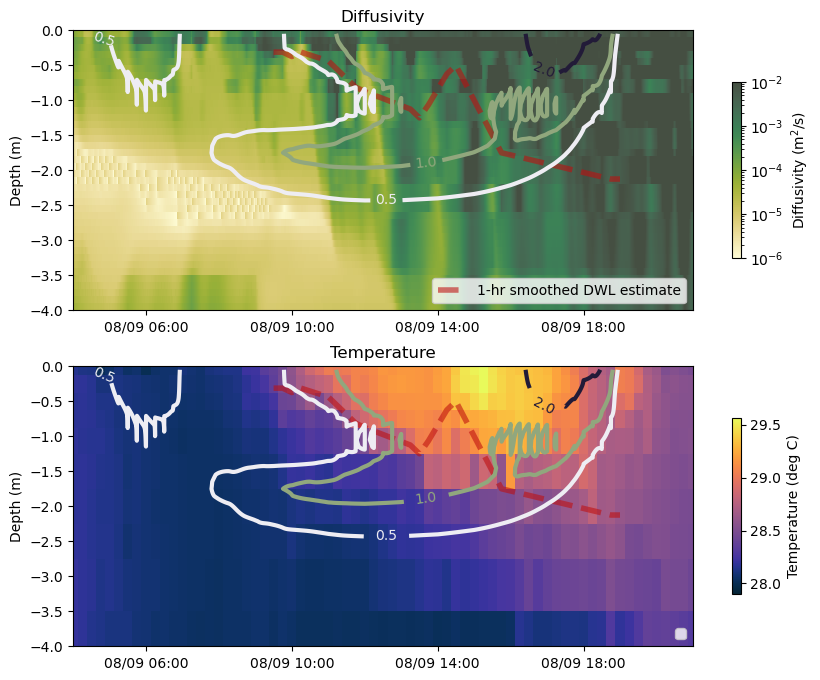

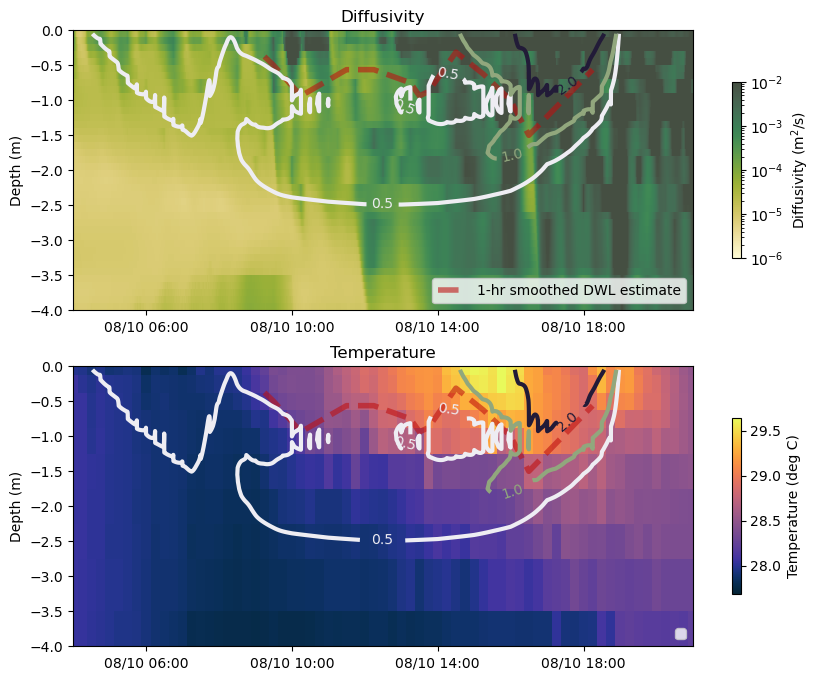

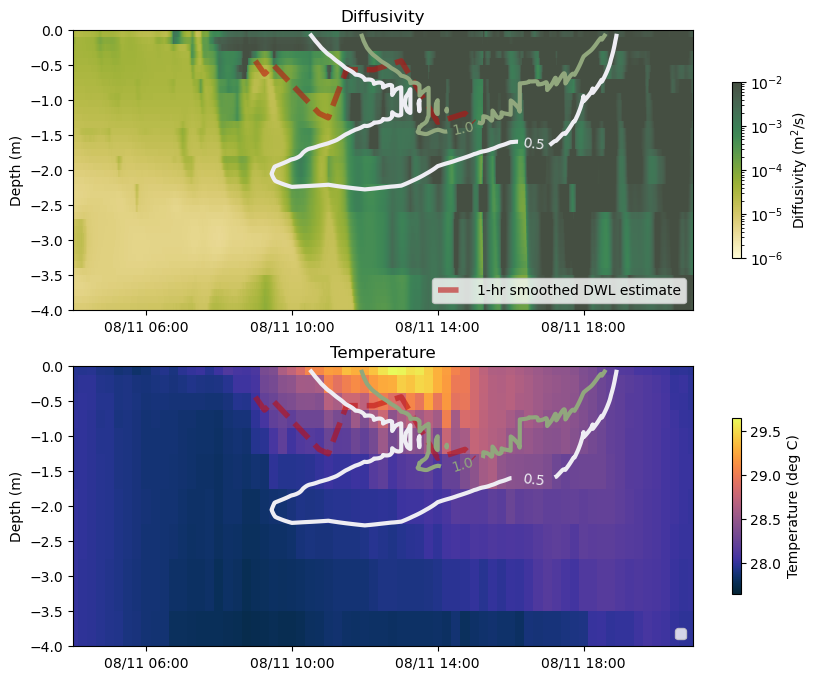

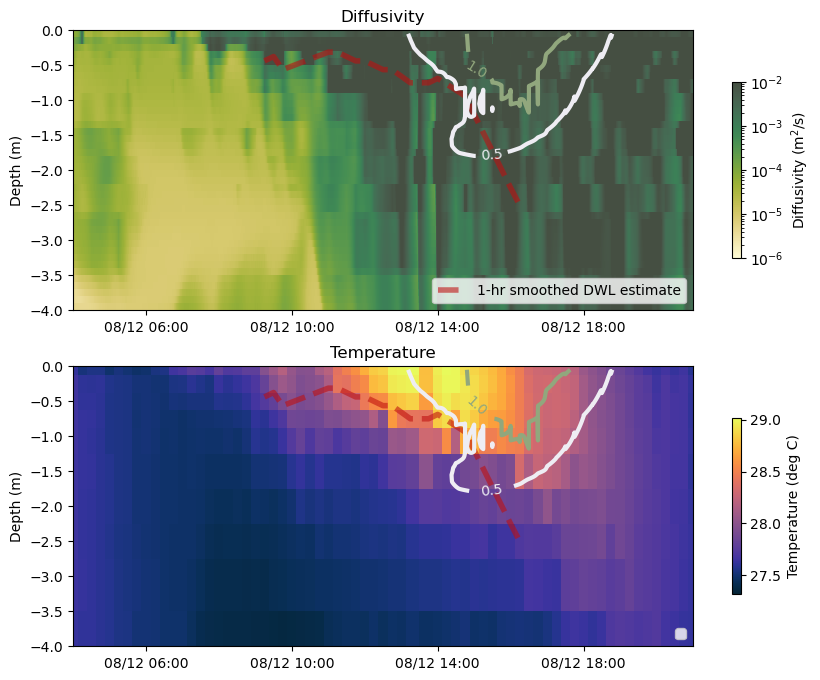

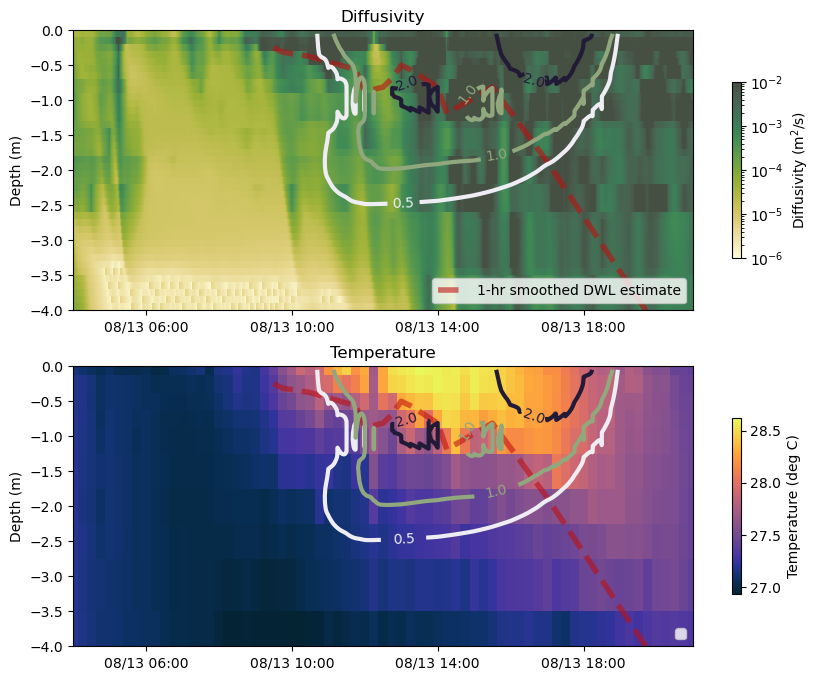

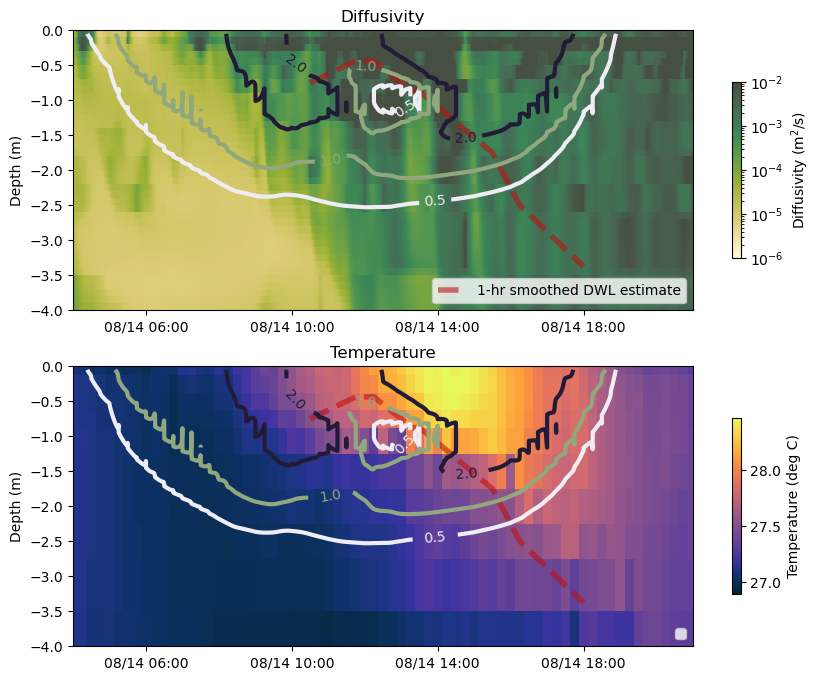

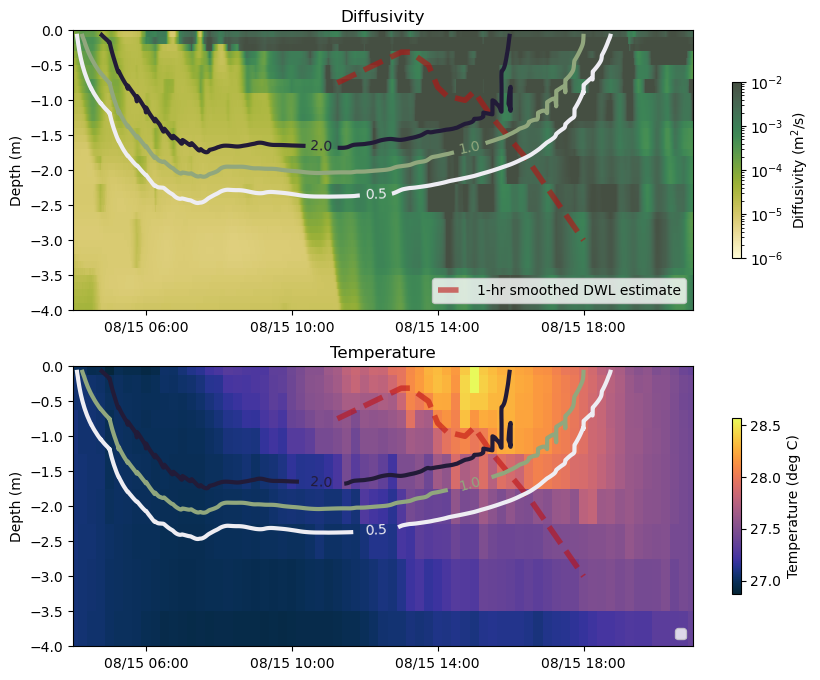

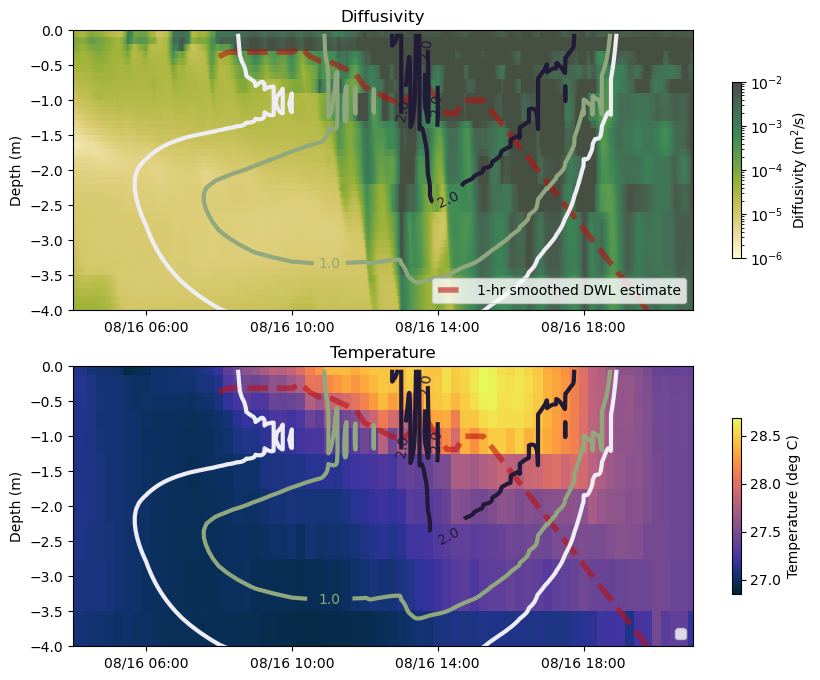

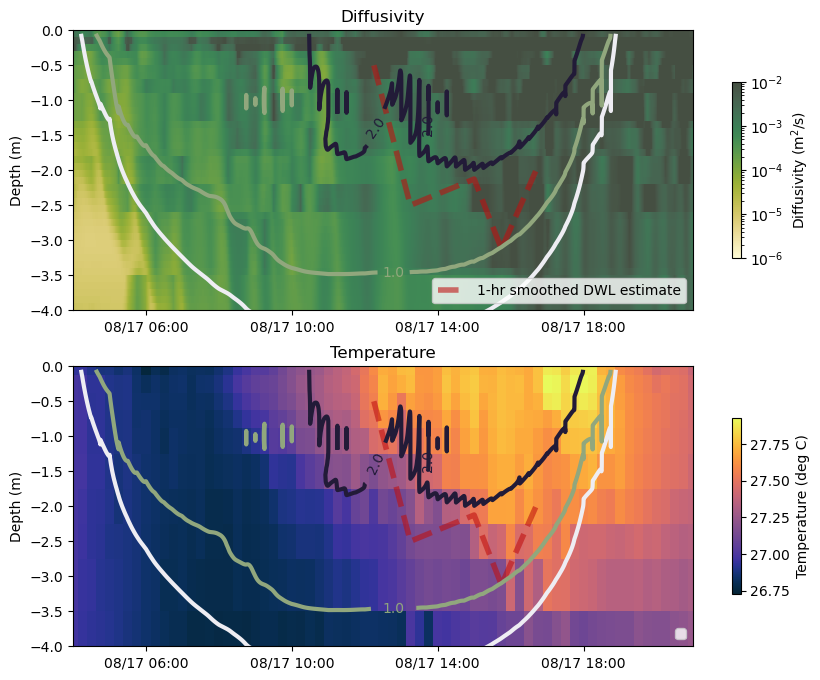

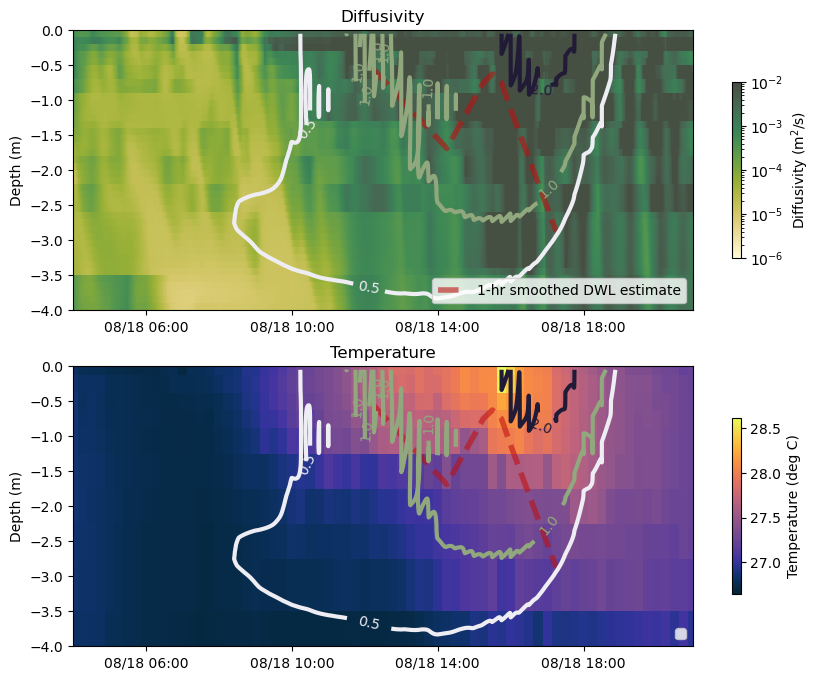

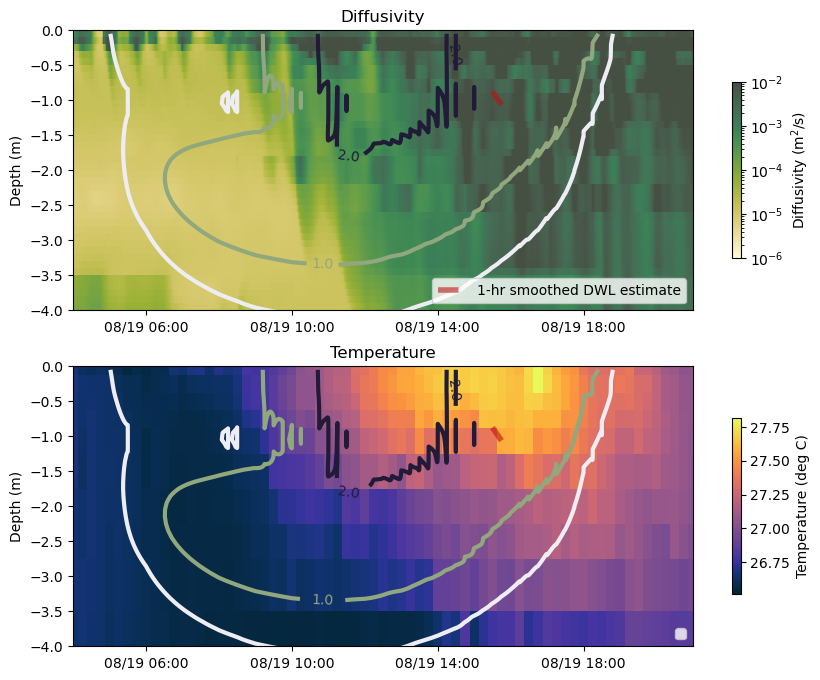

In [103]:
# define mixed depth
d = 6
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

for d in range(6, 20): 
    temp0 = temp.loc[temp.day == d]

    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10,8))

    hydro0 = hydro.isel(time=ds.t.values)
    a = axs[0].pcolormesh(time, -z, hydro0.Kz.values.T, cmap=cmo.cm.speed,  norm=norm, alpha=0.8)#, levels=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],) 
    plt.colorbar(a, ax=axs[0], label='Diffusivity (m$^2$/s)', orientation='vertical', shrink = 0.63) 

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])

    maxs = np.nanmax(dT, axis=0)

    b = axs[1].pcolormesh(X, -Y, Z, cmap=cmo.cm.thermal) #, vmin=26, vmax=29)

    # axs[0].plot(X, -md,"-k", alpha=0.15)
    conv = np.ones(4)/4
    averaged_md = np.convolve(md, conv, mode='same')

    mask = maxs>1
    mask = mask & (X > time[0]) # Crop to daytime hours
    mask = mask & (X < time[-1])

    # axs[0].plot(X[mask], -md[mask], color="#E8E366", linewidth=3, alpha=0.28, label="First cut DWL estimate")
    # axs[1].plot(X[mask], -md[mask],  color="#E8E366",linewidth=3, alpha=0.28)
    axs[1].plot(X[mask], -averaged_md[mask], '--',   color="#BF0F0F" , linewidth=4, alpha=0.58)
    axs[0].plot(X[mask], -averaged_md[mask], '--', color="#BF0F0F",linewidth=4, alpha=0.58, label="1-hr smoothed DWL estimate")
    
    # c = axs[0].scatter(X[mask], -averaged_md[mask], c=maxs[mask], s=40, cmap=cmo.cm.amp, vmin=0, vmax=2) 
    # c = axs[1].scatter(X[mask], -averaged_md[mask], c=maxs[mask], s=40, cmap=cmo.cm.amp, vmin=0, vmax=2) 

    plt.colorbar(b, ax=axs[1], label='Temperature (deg C)', orientation='vertical', shrink = 0.63) 
    # plt.colorbar(c, ax=axs[1], label="dT/dz" , orientation='horizontal', shrink = 0.43) 
    axs[0].legend()
    axs[0].set_title("Diffusivity")
    axs[1].set_title("Temperature")
    for ax in axs: 
        h = ax.contour(time, -z, ds.gamma2.values.T*(86400), cmap=cmo.cm.rain, levels=[0.5, 1, 2], linewidths=3, label="Microcystis growth contour" )#vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)

        plt.clabel(h, inline=1, fontsize=10)
        # ax.plot(mixed_depth['time'], -mixed_depth["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=4, alpha=0.8, color="#3C9FF0", label='Mixed layer depth') 
        ax.set_xlim(time[0], time[-1])
        format_date_ax(ax)
        ax.legend( loc='lower right')
        ax.set_ylim(-4,0)
        ax.set_ylabel("Depth (m)")

/global/homes/s/siennaw/.conda/envs/jup_env/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/global/homes/s/siennaw/.conda/envs/jup_env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


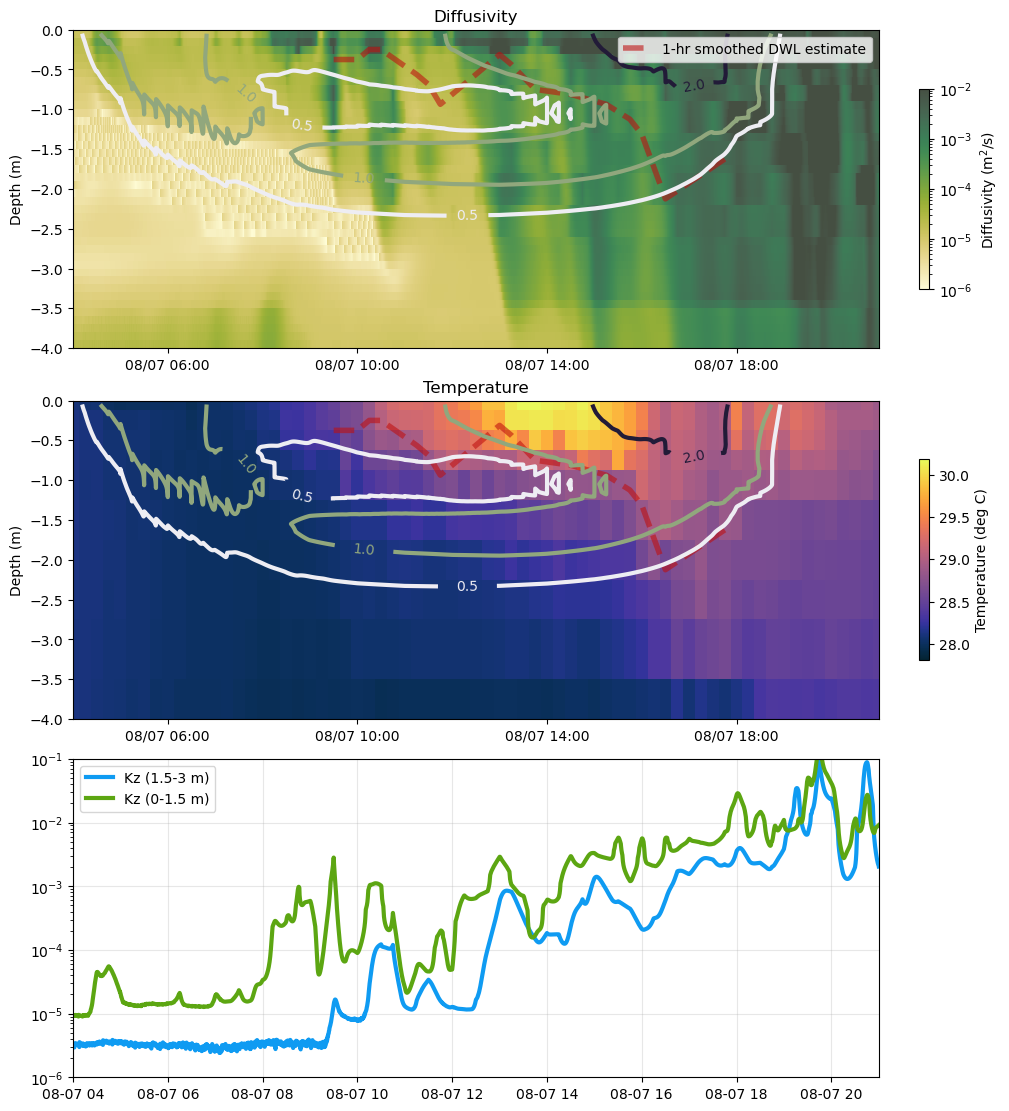

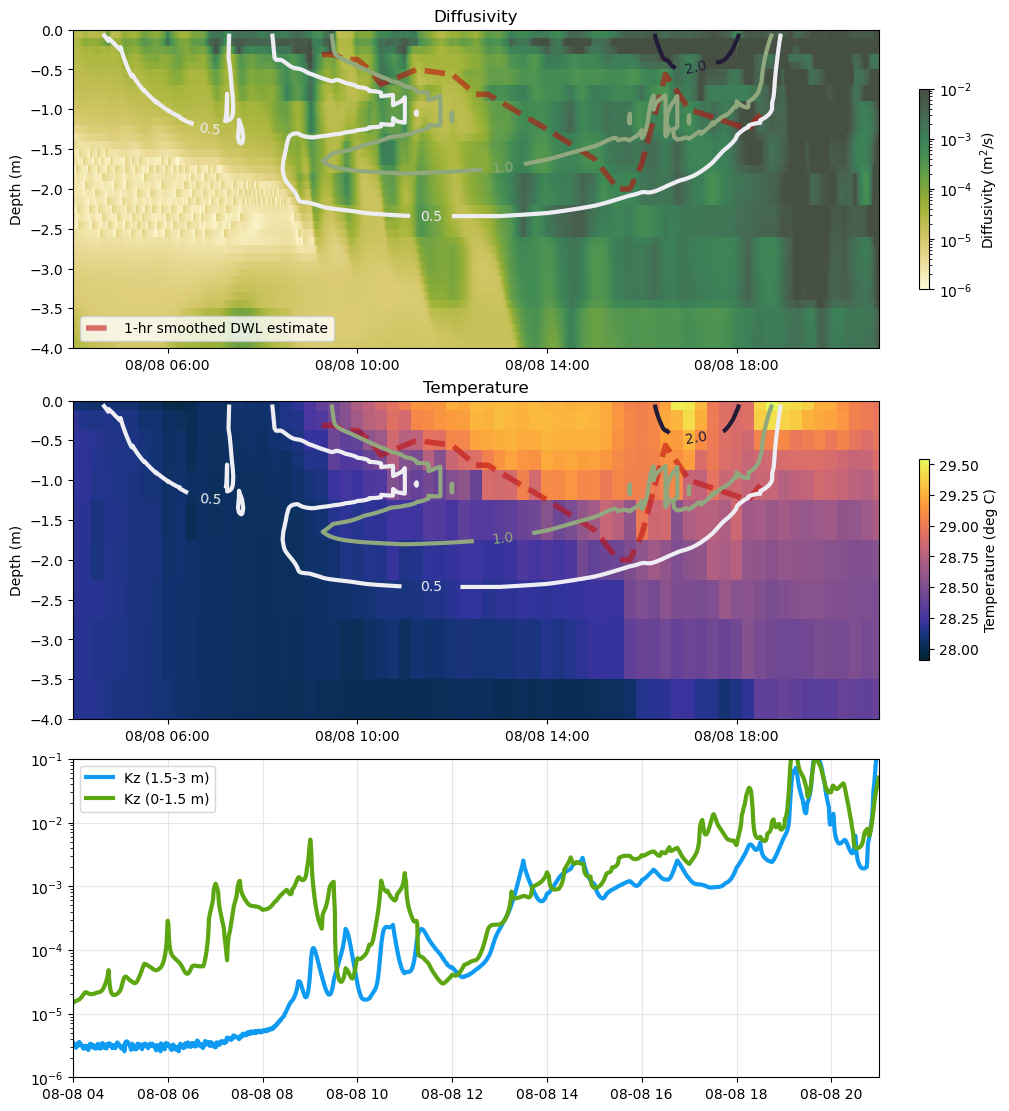

In [120]:
# define mixed depth
d = 6
import matplotlib as mpl
norm = mpl.colors.LogNorm(vmin=1e-6, vmax=1e-2)

for d in range(7, 9): 
    temp0 = temp.loc[temp.day == d]

    ds = guess["%02d" % (d)]
    time = Dates[ds.t.values]

    pivoted = temp0.pivot(index="DEPTH", columns="time", values="TEMP")
    X = pivoted.columns.values
    Y = pivoted.index.values
    Z = pivoted.values

    fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10,11), constrained_layout=True)

    hydro0 = hydro.isel(time=ds.t.values)
    kz = hydro0.Kz.values.T
    a = axs[0].pcolormesh(time, -z, kz, cmap=cmo.cm.speed,  norm=norm, alpha=0.8)#, levels=[1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],) 
    plt.colorbar(a, ax=axs[0], label='Diffusivity (m$^2$/s)', orientation='vertical', shrink = 0.63) 

    dkz = hydro0.Kz.sel(z=slice(1.5,0)).mean(dim='z')-hydro0.Kz.sel(z=slice(3,1.5)).mean(dim='z')
    axs[2].plot(time, hydro0.Kz.sel(z=slice(3,1.5)).mean(dim='z'), color="#0F9BF2", linewidth=3, label="Kz (1.5-3 m)")
    axs[2].plot(time, hydro0.Kz.sel(z=slice(1.5,0)).mean(dim='z'), color="#5CA612", linewidth=3, label="Kz (0-1.5 m)")

    # Caclulate DT/dz 
    dT = np.gradient(Z,  axis=1)/0.1
    dT[0,:] = 0
    mixed_d = np.argmax(dT, axis=0)
    md = np.array([Y[i] for i in mixed_d])

    maxs = np.nanmax(dT, axis=0)

    b = axs[1].pcolormesh(X, -Y, Z, cmap=cmo.cm.thermal) #, vmin=26, vmax=29)

    # axs[0].plot(X, -md,"-k", alpha=0.15)
    conv = np.ones(4)/4
    averaged_md = np.convolve(md, conv, mode='same')

    mask = maxs>1
    mask = mask & (X > time[0]) # Crop to daytime hours
    mask = mask & (X < time[-1])

    axs[1].plot(X[mask], -averaged_md[mask], '--',   color="#BF0F0F" , linewidth=4, alpha=0.58)
    axs[0].plot(X[mask], -averaged_md[mask], '--', color="#BF0F0F",linewidth=4, alpha=0.58, label="1-hr smoothed DWL estimate")
    

    plt.colorbar(b, ax=axs[1], label='Temperature (deg C)', orientation='vertical', shrink = 0.63) 
    axs[0].legend()
    axs[0].set_title("Diffusivity")
    axs[1].set_title("Temperature")
    for ax in axs[0:2]: 
        h = ax.contour(time, -z, ds.gamma2.values.T*(86400), cmap=cmo.cm.rain, levels=[0.5, 1, 2], linewidths=3)#, label="Microcystis growth contour" )#vmin=0, vmax=1e-1)#, vmax=CLIM/10, vmin=0)#, vmin=-1, vmax=1)

        plt.clabel(h, inline=1, fontsize=10)
        ax.set_xlim(time[0], time[-1])
        format_date_ax(ax)
        # ax.legend( loc='lower right')
        ax.set_ylim(-4,0)
        ax.set_ylabel("Depth (m)")
    axs[2].set_yscale('log')
    axs[2].set_xlim(time[0], time[-1])
    axs[2].set_ylim(1e-6, 1e-1)
    axs[2].grid(alpha=0.3)
    axs[2].legend()

Text(0, 0.5, 'Depth (m)')

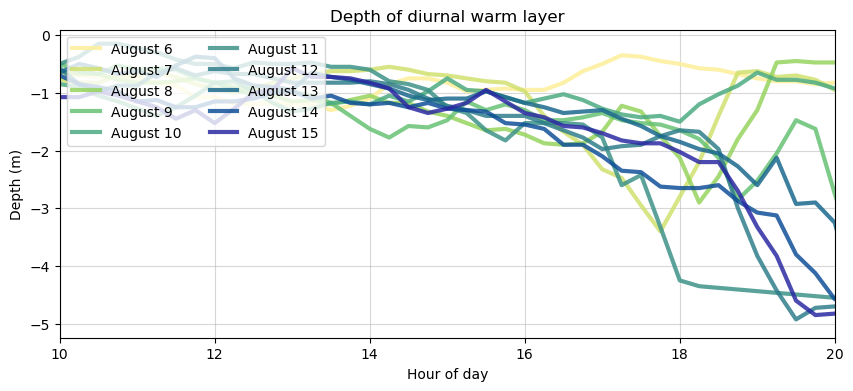

In [ ]:
fig = plt.figure(figsize=(10,4))

mixed_depth['day'] = mixed_depth['time'].dt.day
mixed_depth['hour'] = mixed_depth['time'].dt.hour + mixed_depth['time'].dt.minute/60

for d in range(6, 16): 
    mixed0 = mixed_depth.loc[mixed_depth.day == d]
    plt.plot(mixed0['hour'], -mixed0["Depth_MixedLayer_Max_60min_movavg"], '-', linewidth=3, alpha=0.84, color = cmo.cm.haline_r((d-6)/10), label="August %d" % d) #, color="#3C9

plt.legend(loc ='upper left', ncol=2)
ax = plt.gca()
ax.grid(alpha=0.5)
ax.set_xlim(10, 20)
ax.set_title("Depth of diurnal warm layer")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Depth (m)")

12
13
14
15
16


ValueError: max() iterable argument is empty

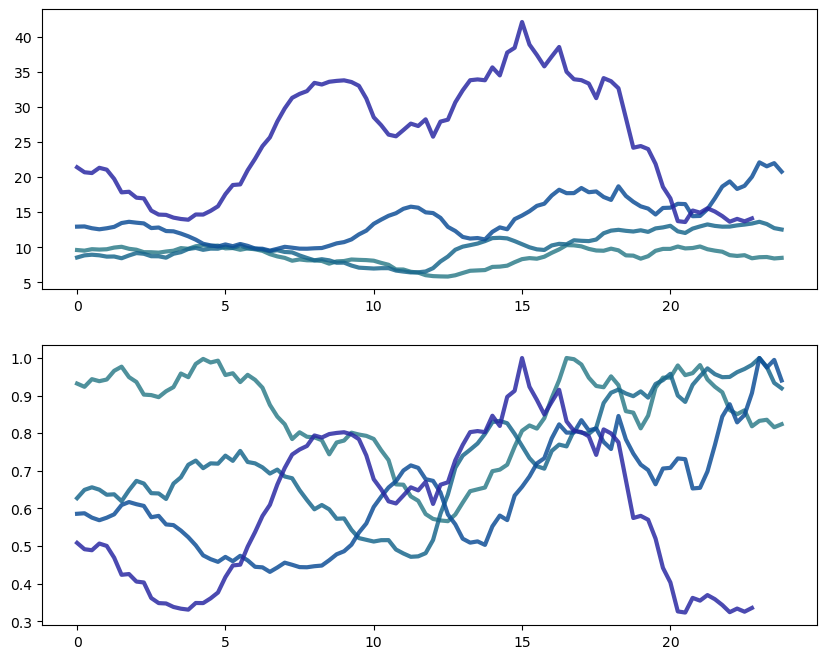

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1 ,figsize=(10,8))
chla['day'] = chla['time'].dt.day
chla['hour'] = chla['time'].dt.hour + chla['time'].dt.minute/60
# print(chla)
for d in range(12, 20): 
    print(d)
    chla0 = chla.loc[chla.day == d]
    axs[1].plot(chla0['hour'], chla0["obs_roll"]/max(chla0["obs_roll"]), '-', linewidth=3, alpha=0.84, color = cmo.cm.haline_r((d-6)/10), label="August %d" % d) #, color="#3C9
    axs[0].plot(chla0['hour'], chla0["obs_roll"]*1e-3, '-', linewidth=3, alpha=0.84, color = cmo.cm.haline_r((d-6)/10), label="August %d" % d) #, color="#3C9

axs[0].legend(loc ='upper left', ncol=2)

for ax in axs:
    ax.grid(alpha=0.5)
    ax.set_xlim(10, 20)
    ax.set_xlabel("Hour of day")
ax.set_title("Normalized chl-a over course of a day")
axs[0].set_ylabel("Chl-a [ug/L]")
axs[1].set_ylabel("Normalized Chl-a [-]")
# ax.set_yscale("log")